# TÊN THÀNH VIÊN
## Trương Hoàng Thành An - 23520032 
## Nguyễn Xuân An - 23520023
## Lê Ngọc Thành - 23521443

In [1]:
import polars as pl
import polars.selectors as cs
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

## `Task 1`: `Loại bỏ` các cột mà nhóm nghĩ là không cần thiết.

### Tạo bảng `item`

In [2]:
data_path = 'recommendation dataset/'

In [3]:
item = pl.read_parquet(data_path + 'sales_pers.item_chunk_0.parquet')
item

p_id,item_id,price,category_l1_id,category_l1,category_l2_id,category_l2,category_l3_id,category_l3,category_id,category,description,brand,manufacturer,creation_timestamp,is_deleted,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,image_url,gender_target,age_group,item_type,gp,weight,color,size,origin,volume,material,sale_status,description_new
i32,str,"decimal[38,4]",i32,str,i32,str,i32,str,i32,str,str,str,str,i64,bool,datetime[μs],datetime[μs],i32,datetime[μs],str,str,str,str,str,"decimal[38,4]",f32,str,str,str,str,str,i32,str
17065,"""0502020000004""",99000.0000,1,"""Babycare""",35,"""Bình sữa, phụ kiện""",7050,"""Núm ty""",7058,"""Núm ty Dr Brown""","""Không xác định""","""Dr.Brown's""","""Không xác định""",1333531544,false,2012-04-04 09:25:44.240,2025-08-18 09:59:19.847,2,2025-07-18 17:59:29.898256,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",36828.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,"""Chi tiết sản phẩm …"
72370,"""0010290040150""",69000.0000,3292,"""Thời trang""",3958,"""Cơ cấu hàng cũ""",7007,"""Thời trang bé trai, bé gái cũ""",6987,"""Bộ quần áo bé gái""","""Không xác định""","""Con Cưng""","""Không xác định""",1503046250,false,2017-08-18 08:50:50.713,2025-09-18 16:05:42.360,null,null,null,"""Không xác định""","""Bé Gái""","""Từ 3Y""","""Bộ quần áo""",0.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,"""Không xác định"""
31154,"""0008010000015""",45000.0000,351,"""Đồ chơi & Sách""",2033,"""0-1Y""",2118,"""Gặm nướu""",2121,"""Gặm nướu khác""","""- Chất liệu: Sản phẩm được làm…","""Thương hiệu khác""","""Không xác định""",1358501584,false,2013-01-18 09:33:04.260,2025-09-27 00:05:36.233,2,2025-07-18 17:59:29.898256,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",14490.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,"""Chi tiết sản phẩm …"
46123,"""0020010000094""",401000.0000,2222,"""Tã""",2272,"""Merries""",2275,"""Merries""",2276,"""Merries_Sơ Sinh""","""﻿﻿Tã dán Merries size S 82 miế…","""Merries Nhật""","""Không xác định""",1400062039,false,2014-05-14 10:07:19.603,2025-09-27 00:05:36.233,2,2025-07-18 17:59:29.898256,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",59749.0000,null,"""Không xác định""","""Không xác định""","""Nhật Bản, Nhật Bản""","""Không xác định""","""Giấy, bột giấy, vải không dệt,…",0,"""Không xác định"""
46127,"""0020010000098""",401000.0000,2222,"""Tã""",2272,"""Merries""",2275,"""Merries""",2278,"""Merries_Tã Quần""","""﻿﻿﻿Bỉm tã quần Merries size M …","""Merries Nhật""","""Không xác định""",1400062040,false,2014-05-14 10:07:20.370,2025-09-27 00:05:36.233,2,2025-07-18 17:59:29.898256,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",65764.0000,null,"""Không xác định""","""Không xác định""","""Nhật Bản, Nhật Bản""","""Không xác định""","""Giấy, bột giấy, vải không dệt,…",0,"""Không xác định"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
157065,"""3389000000238""",129000.0000,3292,"""Thời trang""",6021,"""Thời trang bé gái""",4563,"""Đầm bé gái""",3389,"""Đầm bé gái Animo Easy""","""Không xác định""","""Animo""","""Không xác định""",1740043302,false,2025-02-20 09:21:42.617,2025-09-25 08:05:22.393,2,2025-07-18 17:59:29.898256,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",54386.4000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",1,"""Không xác định"""
157039,"""3389000000212""",129000.0000,3292,"""Thời trang""",6021,"""Thời trang bé gái""",4563,"""Đầm bé gái""",3389,"""Đầm bé gái Animo Easy""","""Không xác định""","""Animo""","""Không xác định""",1740043302,false,2025-02

##### Cột `is_deleted` có giá trị False hết nên loại bỏ cột này

In [4]:
item['is_deleted'].value_counts()

is_deleted,count
bool,u32
false,27332


##### Cột `creation_timestamp` có giá trị trùng với `created_date` cho nên loại bỏ 1 trong 2 cột
##### Tụi em chọn loại bỏ `created_date` vì đa số mô hình như LTSM, ... sử dụng `số giây` cho dễ tính toán
##### Và cột `updated_date` tụi em loại bỏ luôn

In [5]:
item = item.with_columns(
    pl.col("created_date").dt.timestamp("ms")
)

item['created_date']


created_date
i64
1333531544240
1503046250713
1358501584260
1400062039603
1400062040370
…
1740043302617
1740043302617
1740043302617


##### Cột `sync_status_id` có `786` giá trị `Null`, chiếm 2.88%

In [6]:
item['sync_status_id'].value_counts()

sync_status_id,count
i32,u32
null,786
2,26546


##### Cột `last_sync_date` có `786` giá trị `Null`, chiếm 2.88%

In [7]:
item['last_sync_date'].value_counts()

last_sync_date,count
datetime[μs],u32
2025-07-21 10:59:04.045058,5
2025-07-20 10:59:06.647693,2
null,786
2025-07-18 17:59:29.898256,26539


##### Cột `sync_error_message` toàn bộ giá trị là `Null`

In [8]:
item['sync_error_message'].value_counts()

sync_error_message,count
str,u32
null,27332


##### Cột `weight` cũng chỉ chứa giá trị `Null`

In [9]:
item['weight'].value_counts()

weight,count
f32,u32
null,27332


##### Cột `image_url` chỉ chứa giá trị `"Không xác định"`

In [10]:
item['image_url'].value_counts()

image_url,count
str,u32
"""Không xác định""",27332


#### Vì `item_id` và `p_id` ánh xạ 1-1 nên `p_id` sẽ bị loại bỏ

In [11]:
unique_item_id = item.select(pl.col('item_id').n_unique()).item()
unique_p_id = item.select(pl.col('p_id').n_unique()).item()

unique_pairs = item.select(['p_id', 'item_id']).n_unique()

# In kết quả và so sánh
print(f"Số user_id duy nhất:      {unique_item_id}")
print(f"Số customer_id duy nhất:  {unique_p_id}")
print(f"Số cặp (user/customer) duy nhất: {unique_pairs}")

Số user_id duy nhất:      27332
Số customer_id duy nhất:  27332
Số cặp (user/customer) duy nhất: 27332


##### Loại bỏ các cột tên danh mục `(category_l1, category_l2, category_l3, category)` và chỉ giữ lại các cột ID tương ứng `(category_l1_id, category_l2_id, category_l3_id, category_id)`. Vì mỗi cột id đã được ánh xạ 1-1 với cột tên tương ứng

In [12]:
remove_item = [
    'is_deleted',
    'created_date',
    'sync_status_id',
    'last_sync_date',
    'sync_error_message',
    'updated_date',
    'weight',
    'image_url',
    'p_id',
    'category',
    'category_l1',
    'category_l2',
    'category_l3'
]

item = item.drop(remove_item)

### Tạo bảng `purchase_history`

In [13]:
purchase_history = pl.read_parquet(data_path + 'sales_pers.purchase_history_daily_chunk_*.parquet')
purchase_history

timestamp,user_id,item_id,event_type,event_value,price,date_key,quantity,customer_id,created_date,updated_date,channel,payment,location,discount,is_deleted
i64,str,str,str,"decimal[38,4]","decimal[38,4]",i32,i32,i32,datetime[μs],datetime[μs],str,str,i32,"decimal[38,4]",bool
1735064221,"""ca12702ddf55acaa9fb767e10faaa6…","""7115000000004""","""Purchase""",1.0000,49000.0000,20241224,1,5254214,2024-12-24 18:17:01.027,2024-12-24 18:20:09.453,"""In-Store""","""VietQR""",656,0.0000,false
1735068481,"""54314ce86269f4849f9a4c3fc85d94…","""0029130000030""","""Purchase""",1.0000,69000.0000,20241224,1,7573232,2024-12-24 19:28:01.870,2024-12-24 19:28:01.870,"""In-Store""","""Tiền mặt""",143,0.0000,false
1735069843,"""4799de4022b58689b2b9fb37122479…","""3496000000053""","""Purchase""",2.0000,75000.0000,20241224,2,8187418,2024-12-24 19:50:43.760,2024-12-24 19:50:43.760,"""In-Store""","""MoMo""",213,0.0000,false
1735069779,"""4799de4022b58689b2b9fb37122479…","""2700000000002""","""Purchase""",2.0000,58500.0000,20241224,2,8187418,2024-12-24 19:49:39.223,2024-12-24 19:49:39.223,"""In-Store""","""MoMo""",213,13000.0000,false
1735379373,"""3b2423f730815273dfd6f6220b0c5c…","""0029110000036""","""Purchase""",1.0000,89000.0000,20241228,1,6931560,2024-12-28 09:49:33.780,2024-12-28 10:28:49.413,"""Android""","""MoMo""",590,10000.0000,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1729268913,"""a6fc68430e2654c90a06f64be11a98…","""1396000000020""","""Purchase""",1.0000,28050.0000,20241018,1,6848354,2024-10-18 16:28:33.130,2024-10-18 16:28:33.130,"""In-Store""","""Tiền mặt""",446,4950.0000,false
1729345219,"""ac1dddd7c809e0b473d23f36d349eb…","""0007070000403""","""Purchase""",1.0000,189000.0000,20241019,1,5745481,2024-10-19 13:40:19.900,2024-10-19 13:40:19.900,"""iOS""","""Tiền mặt""",228,0.0000,false
1729335081,"""191d6a3053c0dfed3a2a79586e0f89…","""4371000000001""","""Purchase""",1.0000,59000.0000,20241019,1,3307869,2024-10-19 10:51:21.297,2024-10-19 10:51:21.317,"""In-Store""","""Tiền mặt""",368,0.0000,false


##### Cột `is_deleted` có toàn bộ giá trị `False`

In [14]:
purchase_history['is_deleted'].value_counts()

is_deleted,count
bool,u32
false,35729825


##### Cột `event_type` có toàn bộ giá trị là `'Purchase'`

In [15]:
purchase_history['event_type'].value_counts()

event_type,count
str,u32
"""Purchase""",35729825


##### Cột `created_date` có giá trị trùng với `timestamp` nên loại bỏ bởi `timestamp` có sẵn định dạng `unix timestamp`
##### Và cột `updated_date` tụi em loại bỏ luôn

In [16]:
purchase_history = purchase_history.with_columns(
    pl.col("created_date").dt.timestamp("ms")
)

purchase_history['created_date']

created_date
i64
1735064221027
1735068481870
1735069843760
1735069779223
1735379373780
…
1729268913130
1729345219900
1729335081297


##### Cột `date_key` thì có thể được suy luận từ cột `timestamp` (giá trị ngày tháng năm của `timestamp` chính là giá trị của `date_key`)

In [17]:
purchase_history = purchase_history.with_columns(
    pl.col('date_key').cast(pl.Utf8).str.strptime(pl.Date, '%Y%m%d')
)

purchase_history['date_key']

date_key
date
2024-12-24
2024-12-24
2024-12-24
2024-12-24
2024-12-28
…
2024-10-18
2024-10-19
2024-10-19


##### Loại bỏ cột `event_value` vì giống cột `quantity`

In [18]:
so_dong_khac_nhau = purchase_history.select(
    (pl.col('event_value').cast(pl.Int32) != pl.col('quantity')).sum()
).item()
print("Số dòng giống nhau: ", end="")
print(so_dong_khac_nhau)

Số dòng giống nhau: 0


##### Vì `customer_id` ánh xạ 1-1 với `user_id` nên chúng em sẽ loại bỏ `user_id` vì kiểu dữ liệu phức tạp hơn

In [19]:
unique_users = purchase_history.select(pl.col('user_id').n_unique()).item()
unique_customers = purchase_history.select(pl.col('customer_id').n_unique()).item()

# Đếm số cặp (user_id, customer_id) duy nhất - Dòng này đã được sửa
unique_pairs = purchase_history.select(['user_id', 'customer_id']).n_unique()

# In kết quả và so sánh
print(f"Số user_id duy nhất: {unique_users}")
print(f"Số customer_id duy nhất: {unique_customers}")
print(f"Số cặp (user/customer) duy nhất: {unique_pairs}")


Số user_id duy nhất: 2442306
Số customer_id duy nhất: 2442306
Số cặp (user/customer) duy nhất: 2442306


In [20]:
remove_purchase = [
    'is_deleted',
    'event_type',
    'created_date',
    'date_key',
    'updated_date',
    'event_value',
    'user_id'
]

purchase_history = purchase_history.drop(remove_purchase)

### Tạo bảng `user`

In [21]:
user = pl.read_parquet(data_path + '/sales_pers.user_chunk_*.parquet')
user

customer_id,gender,location,province,membership,timestamp,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,region,location_name,install_app,install_date,district,user_id,is_deleted
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],i32,datetime[μs],str,str,str,str,i64,str,str,bool
14732,"""Nam""",155,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - Grand View Phú Mỹ Hưng""","""In-Store""",1306281600,"""7""","""e1e48206652bf8c279ff0206c69a80…",false
15126,"""Nữ""",300,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 121A Nguyễn Duy Trinh""","""In-Store""",1306281600,"""Thủ Đức""","""77891759204bd27e69fb11a7b92889…",false
29718,"""Nữ""",157,"""Bến Tre""","""Standard""",1312126692,2011-07-31 15:38:12.750,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đồng bằng sông Cửu Long""","""BTR - 179 Nguyễn Đình Chiểu""","""In-Store""",1582070400,"""Bến Tre""","""b8041b584a0bb6655361727a0a6108…",false
30077,"""Nữ""",53,"""Hồ Chí Minh""","""Standard""",1314302782,2011-08-25 20:06:22.797,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 101 Trần Quang Khải""","""In-Store""",1314230400,"""1""","""c52ceaca44a83ec41a219cfaff0e05…",false
30085,"""Nữ""",660,"""Hồ Chí Minh""","""Standard""",1314310024,2011-08-25 22:07:04.267,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 85-87 Tây Thạnh""","""In-Store""",1314230400,"""Tân Phú""","""74ac5764f5d67d341aacf238d7762f…",false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
8800478,"""Nữ""",186,"""Đồng Nai""","""Standard""",1749987601,2025-06-15 11:40:01.437,2025-09-23 17:43:56.503,2,2025-07-16 12:17:47.648696,null,"""Đông Nam Bộ""","""DON - 07 Lê Lợi""","""In-Store""",1749945600,"""Long Khánh""","""0a7d1ac011c868e8121f75a86704a7…",false
8814340,"""Nữ""",385,"""Long An""","""Standard""",1750318260,2025-06-19 07:31:00.073,2025-06-19 07:31:00.337,2,2025-07-16 12:17:47.648696,null,"""Đồng bằng sông Cửu Long""","""LAN - 277-278 ĐT835""","""In-Store""",1750291200,"""Bến Lức""","""af28e0cce3fe4a97ad95d4dcd194e6…",false
8810998,"""Nam""",1092,"""Bạc Liêu""","""Standard""",1750234662,2025-06-18 08:17:42.230,2025-06-18 08:17:42.637,2,2025-07-16 12:17:47.648696,null,"""Đồng bằng sông Cửu Long""","""BLI - Phan Ngọc Hiển""","""In-Store""",1750204800,"""Đông Hải""","""7607bd452a7b880af0505c27fd0222…",false


##### Cột `created_date` có giá trị trùng với `timestamp` nên loại bỏ bởi `timestamp` có sẵn định dạng `unix timestamp`
##### Và cột `updated_date` tụi em loại bỏ luôn

In [22]:
user = user.with_columns(
    pl.col("created_date").dt.timestamp("ms")
)

user['created_date']

created_date
i64
1306357911677
1306357911677
1312126692750
1314302782797
1314310024267
…
1749987601437
1750318260073
1750234662230


##### Cột `install_date` cũng bị loại bỏ

In [23]:
user['install_date']

install_date
i64
1306281600
1306281600
1582070400
1314230400
1314230400
…
1749945600
1750291200
1750204800


##### Cột `sync_status_id` có `338285` giá trị `Null`, chiếm `7.4%`

In [24]:
user['sync_status_id'].value_counts()

sync_status_id,count
i32,u32
null,338285
2,4235679


##### Cột `sync_error_message` toàn bộ giá trị là `Null`

In [25]:
user['sync_error_message'].value_counts()

sync_error_message,count
str,u32
null,4573964


##### Cột `last_sync_date` có `338285` giá trị `Null`, chiếm `7.4%`

In [26]:
user['last_sync_date'].value_counts()

last_sync_date,count
datetime[μs],u32
2025-07-16 12:16:22.845873,95270
2025-07-16 12:01:52.777780,98023
2025-07-16 12:04:55.234644,97980
2025-07-18 17:24:30.814181,65944
2025-07-16 11:59:48.811797,97336
…,…
2025-07-16 12:12:30.845994,96719
2025-07-16 12:09:16.850307,96710
2025-07-16 11:56:29.751170,96053


##### Cột `is_deleted` có giá trị `False` hết

In [27]:
user['is_deleted'].value_counts()

is_deleted,count
bool,u32
false,4573964


##### Tương tự bảng Purchase History, chúng em sẽ loại bỏ `user_id`

In [28]:
unique_users = user.select(pl.col('user_id').n_unique()).item()
unique_customers = user.select(pl.col('customer_id').n_unique()).item()

# Đếm số cặp (user_id, customer_id) duy nhất - Dòng này đã được sửa
unique_pairs = user.select(['user_id', 'customer_id']).n_unique()

# In kết quả và so sánh
print(f"Số user_id duy nhất:      {unique_users}")
print(f"Số customer_id duy nhất:  {unique_customers}")
print(f"Số cặp (user/customer) duy nhất: {unique_pairs}")

Số user_id duy nhất:      4573964
Số customer_id duy nhất:  4573964
Số cặp (user/customer) duy nhất: 4573964


#### `Location` ánh xạ 1-1 đến `location_name` nên `location_name` bị loại bỏ

In [29]:
unique_location = user.select(pl.col('location').n_unique()).item()
unique_location_name = user.select(pl.col('location_name').n_unique()).item()

# Đếm số cặp (user_id, customer_id) duy nhất - Dòng này đã được sửa
unique_pairs = user.select(['location', 'location_name']).n_unique()

# In kết quả và so sánh
print(f"Số user_id duy nhất:      {unique_location}")
print(f"Số customer_id duy nhất:  {unique_location_name}")
print(f"Số cặp (user/customer) duy nhất: {unique_pairs}")

Số user_id duy nhất:      995
Số customer_id duy nhất:  995
Số cặp (user/customer) duy nhất: 995


In [30]:
remove_user = [
    'created_date',
    'sync_status_id',
    'sync_error_message',
    'last_sync_date',
    'updated_date',
    'is_deleted',
    'install_date',
    'user_id',
    'location_name'
]

user = user.drop(remove_user)

## `Task 2`: Xử lý `NULL`, Xử lý `Outlier`

In [31]:
# 1. Kiểm tra NULL trong user (sau khi đã loại bỏ cột không cần thiết)
user_null_summary = {}
for col in user.columns:
    null_count = user.select(pl.col(col).is_null().sum()).item()
    total_count = user.height
    null_ratio = null_count / total_count if total_count > 0 else 0
    
    if null_count > 0:
        user_null_summary[col] = {'count': null_count, 'ratio': null_ratio}
        print(f"  {col}: {null_count} NULL values ({null_ratio:.4f})")
    else:
        print(f"  {col}: Không có NULL ✅")

# Xử lý NULL nếu còn tồn tại
if user_null_summary:
    print("\n-------Xử lý các NULL còn lại-------")
    for col, info in user_null_summary.items():
        if info['ratio'] < 0.1:  # Ít hơn 10% NULL
            if col in ['gender', 'membership']:  # Categorical
                # Thay thế bằng mode
                mode_value = user_cleaned.select(pl.col(col).mode().first()).item()
                user_cleaned = user_cleaned.with_columns([
                    pl.col(col).fill_null(mode_value).alias(col)
                ])
                print(f"    {col}: Thay thế NULL bằng mode = {mode_value}")
            else:  # Numeric
                # Thay thế bằng median
                median_value = user_cleaned.select(pl.col(col).median()).item()
                user_cleaned = user_cleaned.with_columns([
                    pl.col(col).fill_null(median_value).alias(col)
                ])
                print(f"    {col}: Thay thế NULL bằng median = {median_value}")
else:
    print("  ✅ Không có NULL nào cần xử lý trong user")

# 2. Kiểm tra NULL trong purchase_history_cleaned
purchase_null_summary = {}
for col in purchase_history.columns:
    null_count = purchase_history.select(pl.col(col).is_null().sum()).item()
    total_count = purchase_history.height
    null_ratio = null_count / total_count if total_count > 0 else 0
    
    if null_count > 0:
        purchase_null_summary[col] = {'count': null_count, 'ratio': null_ratio}
        print(f"  {col}: {null_count} NULL values ({null_ratio:.4f})")
    else:
        print(f"  {col}: Không có NULL ✅")

# Xử lý NULL trong purchase_history nếu cần
if purchase_null_summary:
    print("\n-------Xử lý các NULL còn lại-------")
    for col, info in purchase_null_summary.items():
        if info['ratio'] < 0.05:  # Ít hơn 5% NULL
            if col in ['payment', 'channel']:  # Categorical
                mode_value = purchase_history.select(pl.col(col).mode().first()).item()
                purchase_history_cleaned = purchase_history.with_columns([
                    pl.col(col).fill_null(mode_value).alias(col)
                ])
                print(f"    {col}: Thay thế NULL bằng mode = {mode_value}")
            else:  # Numeric
                median_value = purchase_history.select(pl.col(col).median()).item()
                purchase_history = purchase_history.with_columns([
                    pl.col(col).fill_null(median_value).alias(col)
                ])
                print(f"    {col}: Thay thế NULL bằng median = {median_value}")
        else:
            print(f"    {col}: Quá nhiều NULL ({info['ratio']:.4f}), cần xem xét loại bỏ cột này")
else:
    print("  ✅ Không có NULL nào cần xử lý trong purchase_history")

# 3. Kiểm tra NULL trong item_cleaned
item_null_summary = {}
for col in item.columns:
    null_count = item.select(pl.col(col).is_null().sum()).item()
    total_count = item.height
    null_ratio = null_count / total_count if total_count > 0 else 0
    
    if null_count > 0:
        item_null_summary[col] = {'count': null_count, 'ratio': null_ratio}
        print(f"  {col}: {null_count} NULL values ({null_ratio:.4f})")
    else:
        print(f"  {col}: Không có NULL ✅")

# Xử lý NULL trong item nếu cần
if item_null_summary:
    print("\n-------Xử lý các NULL còn lại-------")
    for col, info in item_null_summary.items():
        if info['ratio'] < 0.1:  # Ít hơn 10% NULL
            if col in ['category_l1', 'category_l2', 'brand', 'manufacturer']:  # Categorical
                mode_value = item.select(pl.col(col).mode().first()).item()
                item_cleaned = item.with_columns([
                    pl.col(col).fill_null(mode_value).alias(col)
                ])
                print(f"    {col}: Thay thế NULL bằng mode = {mode_value}")
            else:  # Numeric
                median_value = item.select(pl.col(col).median()).item()
                item_cleaned = item.with_columns([
                    pl.col(col).fill_null(median_value).alias(col)
                ])
                print(f"    {col}: Thay thế NULL bằng median = {median_value}")
else:
    print("  ✅ Không có NULL nào cần xử lý trong item")

# 4. Xử lý Outliers trong purchase_history
print("\n4. Xử lý Outliers trong purchase_history:")

# Chuyển đổi discount sang float nếu chưa có
if 'discount_float' not in purchase_history.columns:
    purchase_history = purchase_history.with_columns([
        pl.col("discount").cast(pl.Float64).alias("discount_float")
    ])

# Phân tích outliers cho discount
discount_stats = purchase_history.select([
    pl.col("discount_float").quantile(0.25).alias("q1"),
    pl.col("discount_float").quantile(0.75).alias("q3"),
    pl.col("discount_float").median().alias("median")
])

stats_dict = discount_stats.to_dicts()[0]
iqr = stats_dict['q3'] - stats_dict['q1']
lower_bound = stats_dict['q1'] - 1.5 * iqr
upper_bound = stats_dict['q3'] + 1.5 * iqr

print(f"  Discount IQR: {iqr:.2f}")
print(f"  Lower bound: {lower_bound:.2f}")
print(f"  Upper bound: {upper_bound:.2f}")

# Đếm outliers
outlier_count = purchase_history.filter(
    (pl.col("discount_float") < lower_bound) | (pl.col("discount_float") > upper_bound)
).height

print(f"  Số outliers: {outlier_count:,} ({outlier_count/purchase_history.height*100:.2f}%)")

# Xử lý outliers bằng winsorization
print("  → Xử lý outliers bằng winsorization (cắt bỏ)")
purchase_history = purchase_history.with_columns([
    pl.when(pl.col("discount_float") < lower_bound)
    .then(lower_bound)
    .when(pl.col("discount_float") > upper_bound)
    .then(upper_bound)
    .otherwise(pl.col("discount_float"))
    .alias("discount_processed")
])

# 5. Phân tích outliers cho price
print("\n5. Phân tích outliers cho price:")
price_stats = purchase_history.select([
    pl.col("price").quantile(0.25).alias("q1"),
    pl.col("price").quantile(0.75).alias("q3"),
    pl.col("price").median().alias("median")
])

price_stats_dict = price_stats.to_dicts()[0]
price_iqr = price_stats_dict['q3'] - price_stats_dict['q1']
price_lower_bound = price_stats_dict['q1'] - 1.5 * price_iqr
price_upper_bound = price_stats_dict['q3'] + 1.5 * price_iqr

price_outlier_count = purchase_history.filter(
    (pl.col("price") < price_lower_bound) | (pl.col("price") > price_upper_bound)
).height

print(f"  Price outliers: {price_outlier_count:,} ({price_outlier_count/purchase_history.height*100:.2f}%)")

if price_outlier_count / purchase_history.height > 0.05:  # Nếu > 5%
    print("-------Xử lý outliers cho price-------")
    purchase_history = purchase_history.with_columns([
        pl.when(pl.col("price") < price_lower_bound)
        .then(price_lower_bound)
        .when(pl.col("price") > price_upper_bound)
        .then(price_upper_bound)
        .otherwise(pl.col("price"))
        .alias("price_processed")
    ])
else:
    print("  → Không cần xử lý outliers cho price")

  customer_id: Không có NULL ✅
  gender: Không có NULL ✅
  location: Không có NULL ✅
  province: Không có NULL ✅
  membership: Không có NULL ✅
  timestamp: Không có NULL ✅
  region: Không có NULL ✅
  install_app: Không có NULL ✅
  district: Không có NULL ✅
  ✅ Không có NULL nào cần xử lý trong user
  timestamp: Không có NULL ✅
  item_id: Không có NULL ✅
  price: Không có NULL ✅
  quantity: Không có NULL ✅
  customer_id: Không có NULL ✅
  channel: Không có NULL ✅
  payment: Không có NULL ✅
  location: Không có NULL ✅
  discount: Không có NULL ✅
  ✅ Không có NULL nào cần xử lý trong purchase_history
  item_id: Không có NULL ✅
  price: Không có NULL ✅
  category_l1_id: Không có NULL ✅
  category_l2_id: Không có NULL ✅
  category_l3_id: Không có NULL ✅
  category_id: Không có NULL ✅
  description: Không có NULL ✅
  brand: Không có NULL ✅
  manufacturer: Không có NULL ✅
  creation_timestamp: Không có NULL ✅
  gender_target: Không có NULL ✅
  age_group: Không có NULL ✅
  item_type: Không có 

## **Task 3: Phân tích tương đồng**

### **Phân tích tương đồng trên dữ liệu Items**

#### Chia các đặc trưng vào 2 nhóm số và phân loại
#### Loại bỏ `description` và `description_new` vì đây là text tự do, không có ý nghĩa thống kê
#### Loại bỏ `item_id` vì đó là mã định danh duy nhất không có ý nghĩa thống kê

In [32]:
num_cols = ['price', 'creation_timestamp', 'gp', 'sale_status']
remove = ['description', 'description_new', 'item_id']
cat_cols = [cc for cc in item.columns if cc not in num_cols and cc not in remove]

### Hàm vẽ ma trận tương quan pearson

In [33]:
def pearson_heatmap(data, num_cols, cat_cols):
    df = data
    corr_dict = {}
    for c1 in num_cols:
        corr_dict[c1] = [
            df.select(pl.corr(c1, c2)).item() for c2 in num_cols
        ]
    
    corr_matrix = pl.DataFrame(corr_dict, schema=num_cols, orient="col")
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix.to_pandas(),
        xticklabels=num_cols,
        yticklabels=num_cols,
        annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5
    )
    plt.title("Ma trận Tương quan Pearson cho các Thuộc tính số", fontsize=16)
    plt.show()
    
    # In kết quả
    cols = corr_matrix.columns
    
    # 1️⃣ Chuyển ma trận thành dạng (col1, col2, corr)
    pairs = []
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if i < j:  # tránh lặp (A,B) & (B,A)
                val = corr_matrix[c1][j]  # giá trị tại hàng j, cột c1
                pairs.append((c1, c2, abs(val)))
    
    df_corr_pairs = pl.DataFrame(pairs, schema=["col1", "col2", "corr"], orient="row")
    
    # 2️⃣ Lọc và sắp xếp
    high_corr_pairs = (
        df_corr_pairs
        .filter((pl.col("corr") > 0.8) & (pl.col("corr") <= 1))
        .sort("corr", descending=True)
    )
    
    # 3️⃣ In kết quả
    print("Các cặp thuộc tính số có tương quan cao (> 0.8):")
    if not high_corr_pairs.is_empty():
        print(high_corr_pairs.to_pandas())
    else:
        print("Không có")

### In kết quả

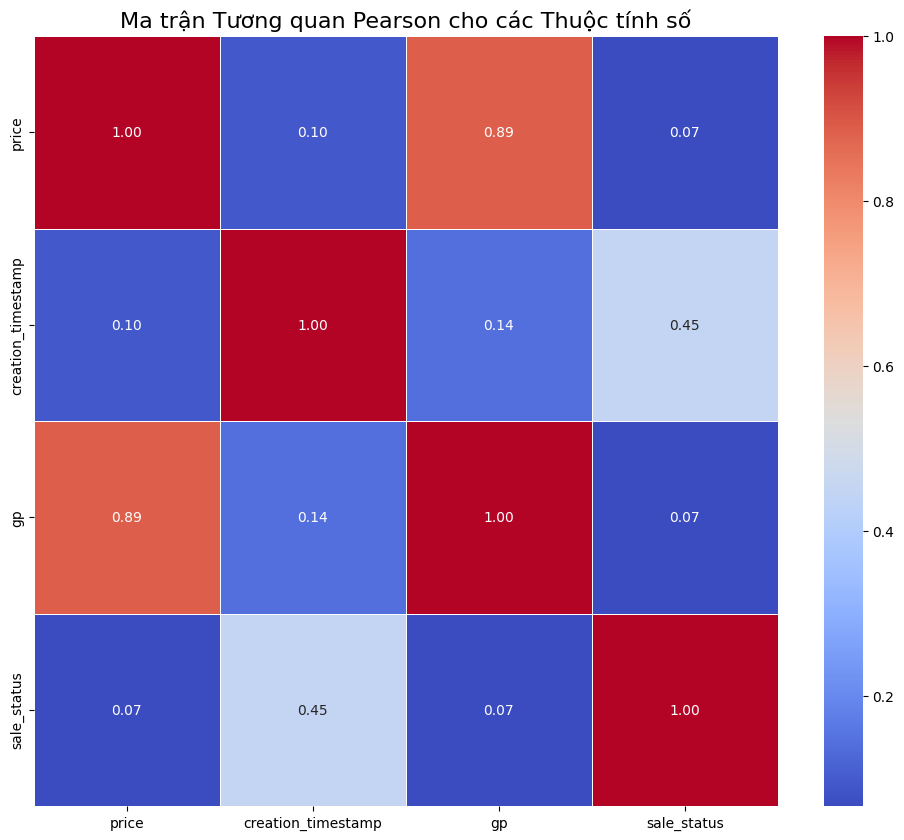

Các cặp thuộc tính số có tương quan cao (> 0.8):
    col1 col2      corr
0  price   gp  0.886709


In [34]:
pearson_heatmap(item, num_cols, cat_cols)

#### Vẽ biểu đồ phân tán để xem mối quan hệ và tính toán tỷ lệ giữa `price` và `gp` để tiến hành phân tích mối tương đồng giữa 2 đặc trưng này

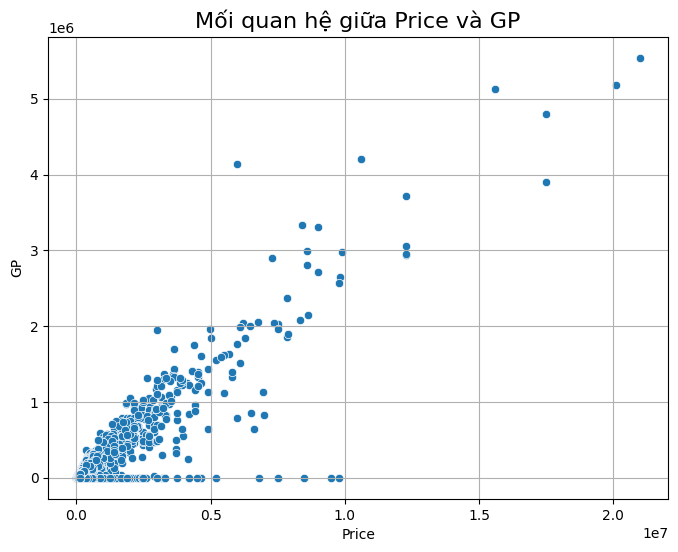

In [35]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=item['price'], y=item['gp'])
plt.title('Mối quan hệ giữa Price và GP', fontsize=16)
plt.xlabel('Price')
plt.ylabel('GP')
plt.grid(True)
plt.show()

#### Tính toán và kiểm tra tỷ lệ giữa gp và price

In [36]:
item_with_ratio = item.filter(pl.col("price") != 0).with_columns(
    (pl.col("gp") / pl.col("price")).alias("gp_price_ratio")
)

# Xem thống kê của cột tỷ lệ này
print("--- Thống kê tỷ lệ gp / price ---")
print(item_with_ratio.select("gp_price_ratio").describe())


--- Thống kê tỷ lệ gp / price ---
shape: (9, 2)
┌────────────┬────────────────┐
│ statistic  ┆ gp_price_ratio │
│ ---        ┆ ---            │
│ str        ┆ f64            │
╞════════════╪════════════════╡
│ count      ┆ 27331.0        │
│ null_count ┆ 0.0            │
│ mean       ┆ 0.23445        │
│ std        ┆ 0.190201       │
│ min        ┆ 0.0            │
│ 25%        ┆ 0.0            │
│ 50%        ┆ 0.257          │
│ 75%        ┆ 0.3892         │
│ max        ┆ 1.0            │
└────────────┴────────────────┘


#### Vì `gp` gần như tuyến tính theo `price` với hệ số khoảng 0.23, nên chúng em sẽ bỏ `gp` và chỉ giữ `price`

In [37]:
item = item.drop('gp')
num_cols.remove('gp')

### Hàm tính Cramer's V

In [38]:
def cramers_v(df: pl.DataFrame, col_x: str, col_y: str) -> float:
    # Chuyển 2 cột cần thiết sang pandas để tính toán
    df_pd = df.select([col_x, col_y]).to_pandas()
    
    # Tạo bảng tần suất chéo (contingency table)
    contingency_table = pd.crosstab(df_pd[col_x], df_pd[col_y])
    
    # Tính toán Chi-Squared
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    
    # Xử lý trường hợp không có dữ liệu
    if n == 0:
        return 0.0
        
    phi2 = chi2 / n
    r, k = contingency_table.shape
    
    # Hiệu chỉnh bias
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0.0
        
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

### Vẽ ma trận tương quan Cramer's V

In [39]:
# --- BƯỚC 3: PHÂN TÍCH LIÊN HỆ CHO DỮ LIỆU PHÂN LOẠI (POLARS) ---
print("--- Phân tích Liên hệ cho Dữ liệu Phân loại (Polars) ---")

def cramers_v_heatmap(data, num_cols, cat_cols):
    df = data
    # TẠO MA TRẬN CRAMÉR'S V 
    cols = cat_cols
    m = len(cols)
    
    # Tính trên tam giác trên để tiết kiệm, sau đó đối xứng
    mat = np.zeros((m, m), dtype=float)
    for i, c1 in enumerate(cols):
        mat[i, i] = 1.0
        for j in range(i + 1, m):
            c2 = cols[j]
            v = cramers_v(df, c1, c2)
            mat[i, j] = v
            mat[j, i] = v
            
    cramers_matrix_pd = pd.DataFrame(mat, index=cols, columns=cols)
    
    # VẼ HEATMAP 
    plt.figure(figsize=(16, 12))
    sns.heatmap(cramers_matrix_pd, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
    plt.title("Ma trận Liên hệ Cramér's V cho các Thuộc tính Phân loại (Polars)", fontsize=16)
    plt.show()
    
    # LIỆT KÊ CẶP LIÊN HỆ MẠNH (> 0.7) 
    # Lấy cặp i<j để không trùng (A,B) và (B,A)
    pairs = []
    for i in range(m):
        for j in range(i + 1, m):
            pairs.append((cols[i], cols[j], abs(mat[i, j])))
    
    df_pairs = pl.DataFrame(pairs, schema=["col1", "col2", "cramers_v"], orient="row")
    
    strong_pairs = (
        df_pairs
        .filter((pl.col("cramers_v") > 0.7) & (pl.col("cramers_v") <= 1))
        .sort("cramers_v", descending=True)
    )
    
    print("Các cặp thuộc tính phân loại có liên hệ mạnh (> 0.7):")
    if not strong_pairs.is_empty():
        print(strong_pairs.to_pandas())
    else:
        print("Không có")


--- Phân tích Liên hệ cho Dữ liệu Phân loại (Polars) ---


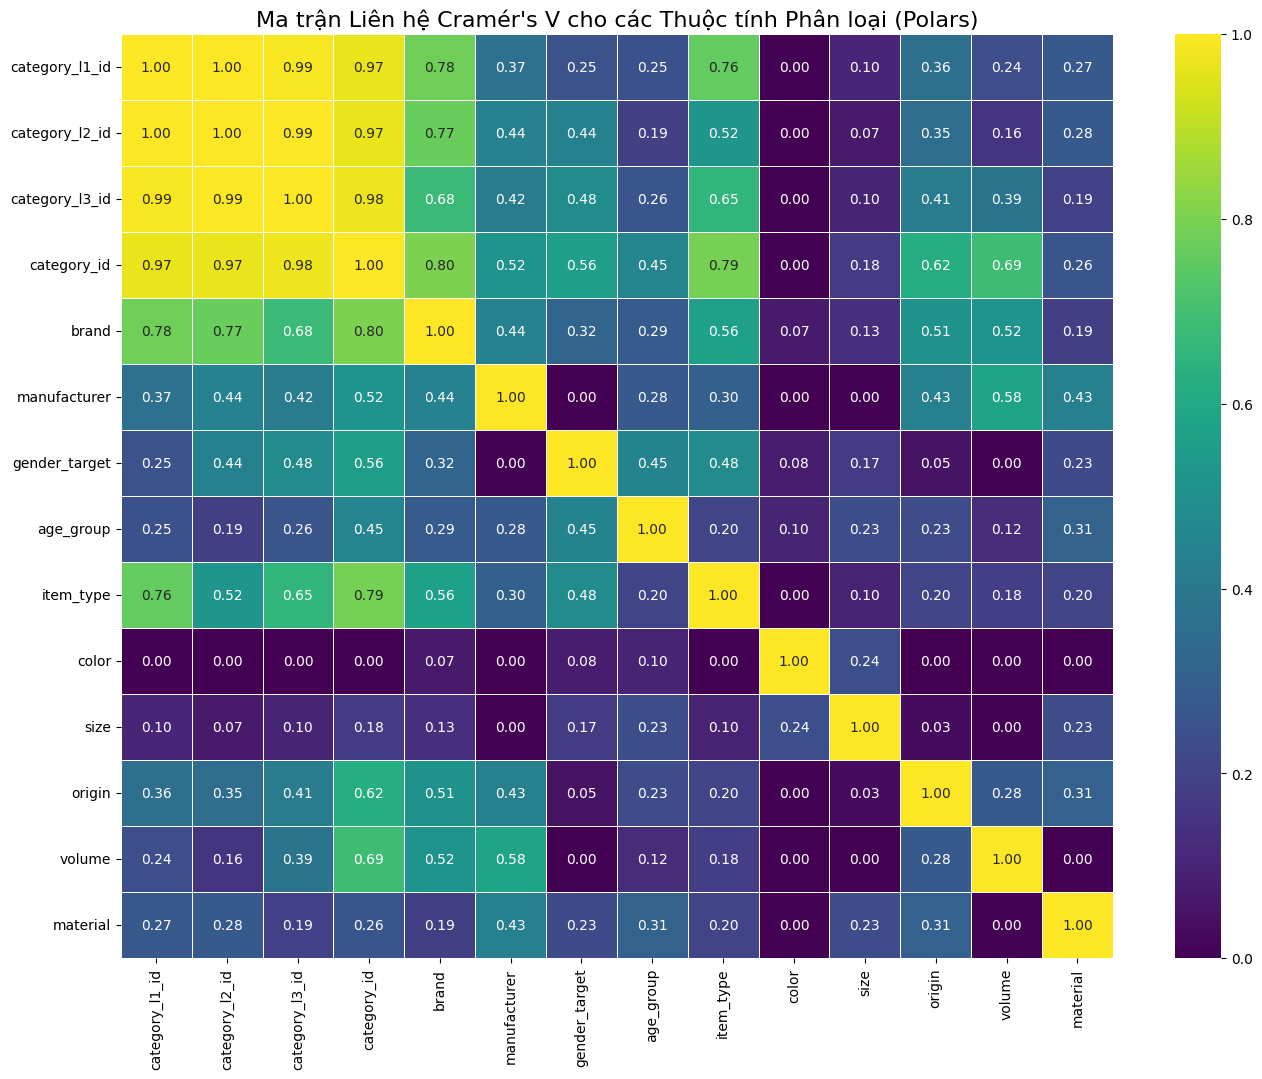

Các cặp thuộc tính phân loại có liên hệ mạnh (> 0.7):
              col1            col2  cramers_v
0   category_l1_id  category_l2_id   0.997728
1   category_l2_id  category_l3_id   0.992914
2   category_l1_id  category_l3_id   0.990658
3   category_l3_id     category_id   0.975262
4   category_l2_id     category_id   0.968351
5   category_l1_id     category_id   0.966151
6      category_id           brand   0.800792
7      category_id       item_type   0.792279
8   category_l1_id           brand   0.780305
9   category_l2_id           brand   0.769862
10  category_l1_id       item_type   0.761148


In [40]:
cramers_v_heatmap(item, num_cols, cat_cols)

#### **Nhận xét**
##### **Nhóm các category**: Vì các đặc trưng `category_l1_id`, `category_l2_id`, `category_l3_id` có mức tương quan rất cao (Cramér’s V > 0.94) và chỉ là các cấp con trong cùng hệ thống danh mục với `category_id`, nên ta loại bỏ ba đặc trưng này và chỉ giữ lại `category_id`

##### **Nhóm brand và các category**: Vì `brand` và `category_id` có Cramér's V = 0.80 (liên hệ mạnh nhưng vẫn còn 20% thông tin độc lập, và `brand` là đặc trưng quan trọng thể hiện thương hiệu - một khía cạnh khác với phân loại sản phẩm), nên ta giữ cả hai.

##### **Nhóm item_type và các category**: Vì item_type và category_id có Cramér's V = 0.79 (liên hệ mạnh nhưng item_type mô tả loại hình sản phẩm còn category mô tả nhóm sản phẩm - hai góc nhìn bổ sung cho nhau), nên ta giữ cả hai.

In [41]:
remove = ['category_l1_id', 'category_l2_id', 'category_l3_id']
item = item.drop(remove)
cat_cols = [c for c in cat_cols if c not in remove]

### Hàm tính Correlation Ratio (η²)

In [42]:
def correlation_ratio(categories, values):
    categories = np.array(categories)
    values = np.array(values)
    mask = ~(pd.isna(categories) | pd.isna(values))
    categories = categories[mask]
    values = values[mask]
    
    if len(values) == 0 or len(np.unique(categories)) <= 1:
        return 0.0
    
    overall_mean = np.mean(values)
    sst = np.sum((values - overall_mean) ** 2)
    
    if sst == 0:
        return 0.0
    
    ssb = 0
    for cat in np.unique(categories):
        cat_values = values[categories == cat]
        if len(cat_values) > 0:
            ssb += len(cat_values) * (np.mean(cat_values) - overall_mean) ** 2
    
    return ssb / sst


In [43]:
def compute_correlation_ratio_matrix(data, num_cols, cat_cols,
                                      sample_size=None):
    
    # SAMPLING 
    if sample_size and len(data) > sample_size:
        data_sample = data.sample(n=sample_size, seed=42)
    else:
        data_sample = data
    
    # CHUYỂN SANG PANDAS 
    cols_needed = cat_cols + num_cols
    df = data_sample.select(cols_needed).to_pandas()
    
    # TÍNH MA TRẬN 
    correlation_matrix = pd.DataFrame(
        index=cat_cols,
        columns=num_cols,
        dtype=float
    )
    
    total_pairs = len(cat_cols) * len(num_cols)
    computed = 0
    
    for cat_col in cat_cols:
        for num_col in num_cols:
            try:
                correlation_matrix.loc[cat_col, num_col] = float(
                    correlation_ratio(df[cat_col], df[num_col])
                )
                computed += 1
            except Exception as e:
                print(f"  ⚠️ Lỗi tại ({cat_col}, {num_col}): {str(e)}")
                correlation_matrix.loc[cat_col, num_col] = np.nan
    
    # Xóa dữ liệu pandas để giải phóng RAM
    del df
    import gc
    gc.collect()
    
    correlation_matrix = correlation_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)
    
    # ========== BƯỚC 5: TÌM CẶP TƯƠNG QUAN CAO ==========
    threshold = 0.7
    high_corr_pairs = []
    
    for cat_col in correlation_matrix.index:
        for num_col in correlation_matrix.columns:
            eta_sq = correlation_matrix.loc[cat_col, num_col]
            if not pd.isna(eta_sq) and eta_sq > threshold:
                high_corr_pairs.append({
                    'Categorical': cat_col,
                    'Numeric': num_col,
                    'η²': eta_sq
                })
    
    print(f"\n{'='*80}")
    print(f"CÁC CẶP FEATURE CÓ η² > {threshold}:")
    print("=" * 80)
    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('η²', ascending=False)
        print(high_corr_df.to_string(index=False))
    else:
        print(f"Không có cặp nào có η² > {threshold}")
    
    # ========== BƯỚC 6: VẼ HEATMAP ==========
    n_rows = len(correlation_matrix.index)
    n_cols = len(correlation_matrix.columns)
    fig_width = max(10, n_cols * 1.5)
    fig_height = max(8, n_rows * 0.6)
    
    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(
        correlation_matrix.astype(float), 
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        cbar_kws={'label': 'η²', 'shrink': 0.8},
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor='gray',
        annot_kws={'fontsize': 9}
    )
    plt.title('Ma trận tương quan Số-Phân loại (η²)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Đặc trưng Số', fontsize=13, fontweight='bold')
    plt.ylabel('Đặc trưng Phân loại', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()


CÁC CẶP FEATURE CÓ η² > 0.7:
Categorical Numeric       η²
category_id   price 0.833225


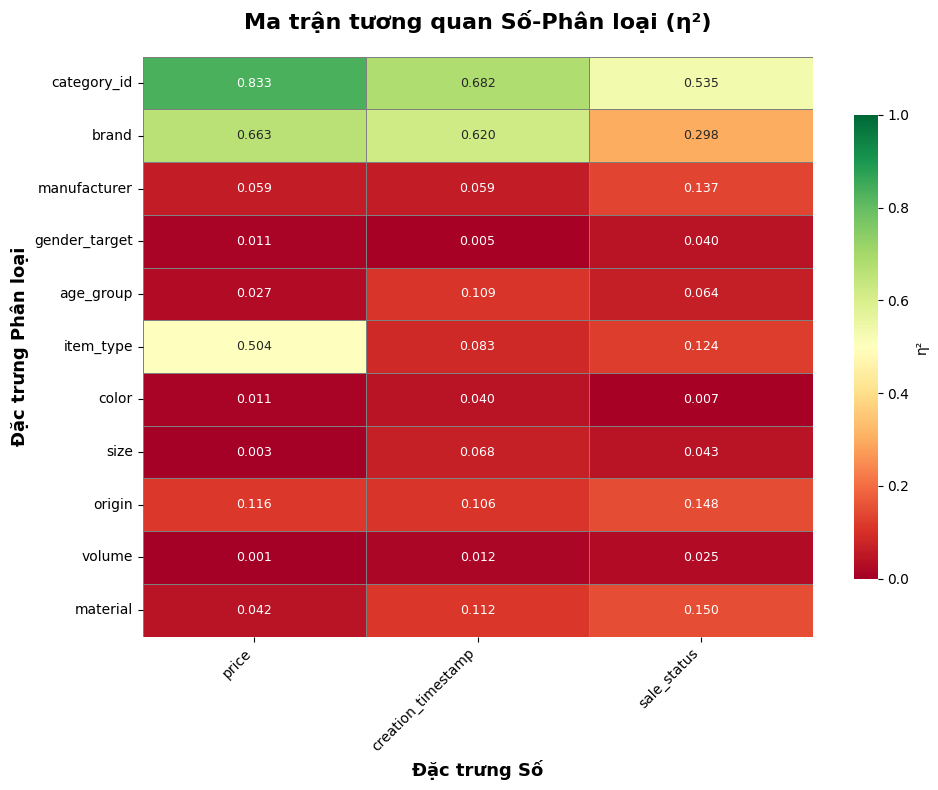

In [44]:
compute_correlation_ratio_matrix(
    item, 
    num_cols, 
    cat_cols,
    sample_size=None
)

#### Vì category_id giải thích được 83% phương sai của price (η² = 0.83), chứng tỏ giá sản phẩm phụ thuộc mạnh vào category (Ví dụ: Điện thoại thường sẽ đắt hơn quần áo, sách vở)

### **Phân tích tương đồng trên dữ liệu User**
#### Không sử dụng customer_id vì đây là cột định danh không có giá trị so sánh tương quan

In [45]:
num_cols = ['timestamp']
cat_cols = [cc for cc in user.columns if cc not in num_cols]
cat_cols.remove('customer_id')

#### Vì đặc trưng số chỉ có 1 đặc trưng nên chúng em sẽ không phân tích độ tương quan đặc trưng số - số

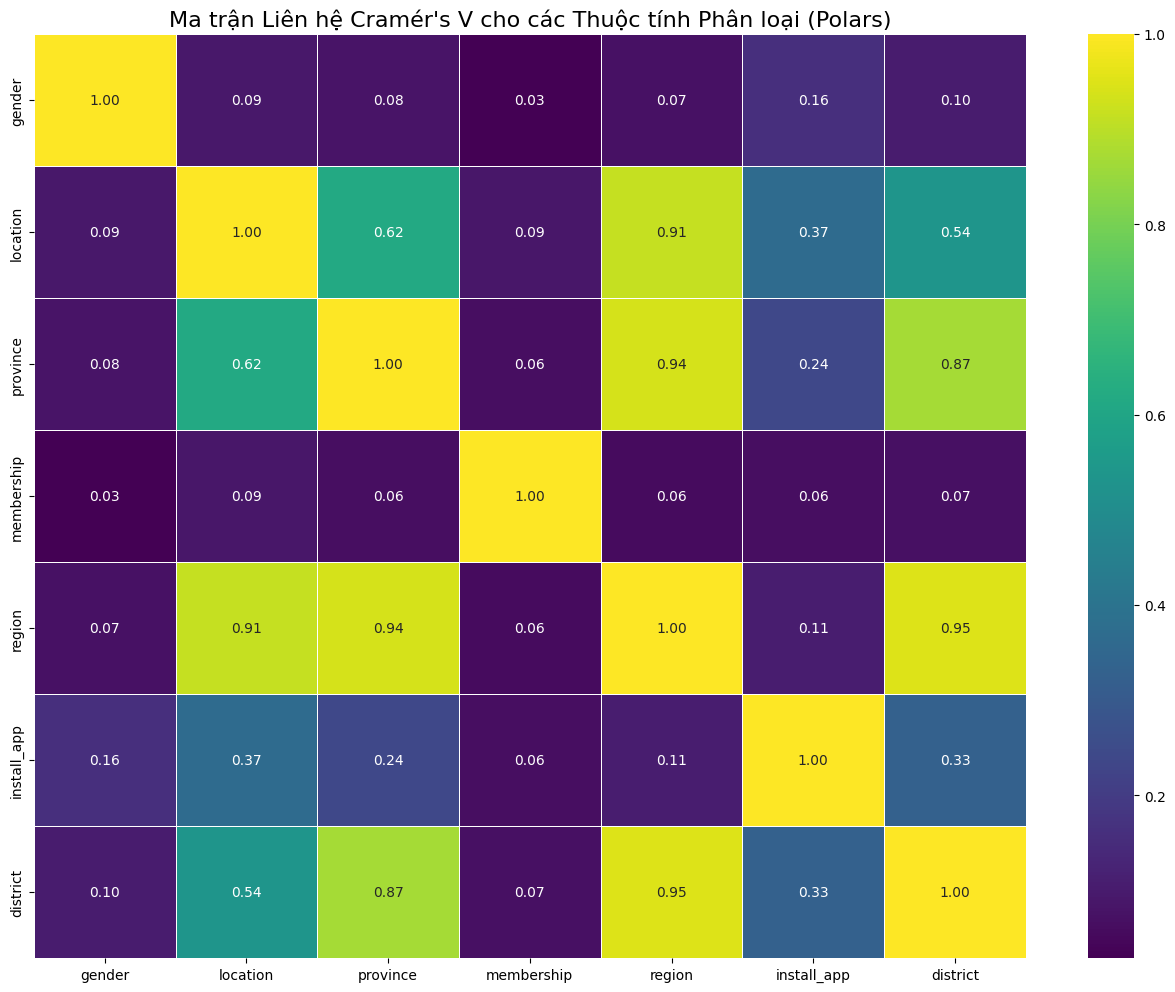

Các cặp thuộc tính phân loại có liên hệ mạnh (> 0.7):
       col1      col2  cramers_v
0    region  district   0.950595
1  province    region   0.937743
2  location    region   0.913224
3  province  district   0.868616


In [46]:
cramers_v_heatmap(user, num_cols, cat_cols)

#### Các biến địa lý trong bảng user như region, province, district, location, location_name có độ tương quan rất cao (Cramér’s V > 0.9), cho thấy chúng gần như mô tả cùng một thông tin ở các cấp hành chính khác nhau.
#### Giữ lại đặc trưng `province` vì nó đủ cân bằng giữa mức độ chi tiết và khả năng khái quát, thể hiện rõ khác biệt vùng miền mà vẫn có số lượng nhóm hợp lý, giúp mô hình học được xu hướng địa lý mà không bị phân mảnh

In [47]:
remove = ['region', 'district', 'location']
user = user.drop(remove)
cat_cols = [c for c in cat_cols if c not in remove]


CÁC CẶP FEATURE CÓ η² > 0.7:
Không có cặp nào có η² > 0.7


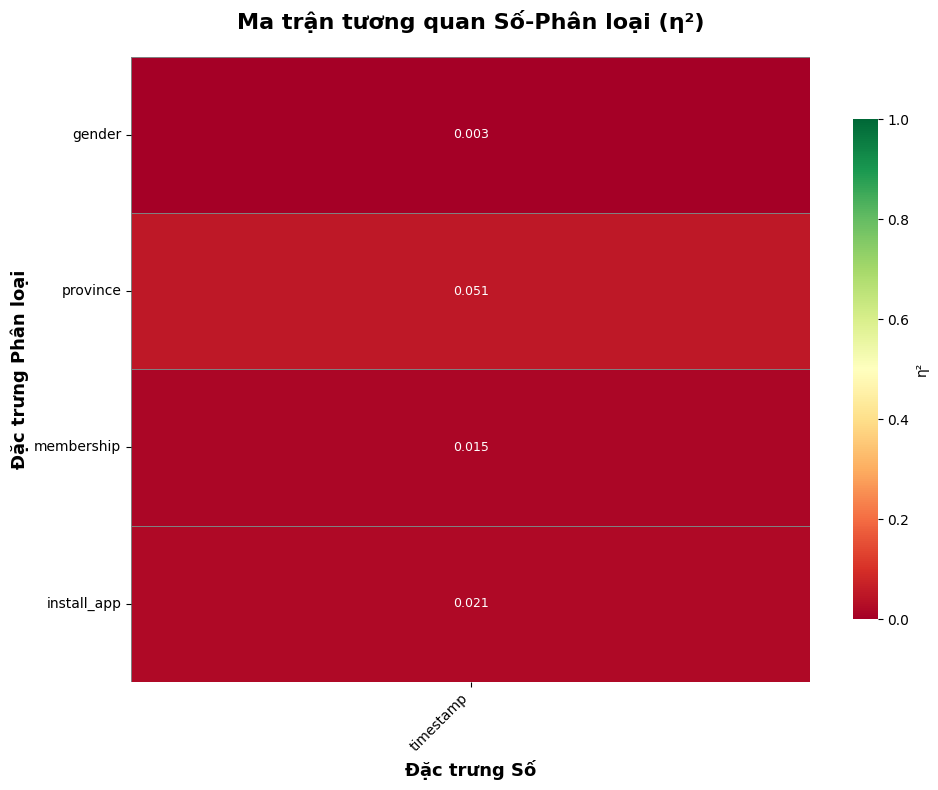

In [48]:
compute_correlation_ratio_matrix(
    user, 
    num_cols, 
    cat_cols,
    sample_size=None
)

### **Phân tích tương đồng trên dữ liệu Purchase History**

#### Tương tự như dữ liệu user, chúng em cũng sẽ loại bỏ `customer_id`, `item_id` không đem đi phân tích vì đây chỉ là mã định danh duy nhất cho từng sản phẩm, không phản ánh thông tin thống kê hay phân loại tự nhiên

In [49]:
num_cols = ['timestamp', 'price', 'quantity', 'discount', 'discount_float', 'discount_processed', 'price_processed']
cat_cols = [cc for cc in purchase_history.columns if cc not in num_cols]
cat_cols.remove('customer_id')
cat_cols.remove('item_id')

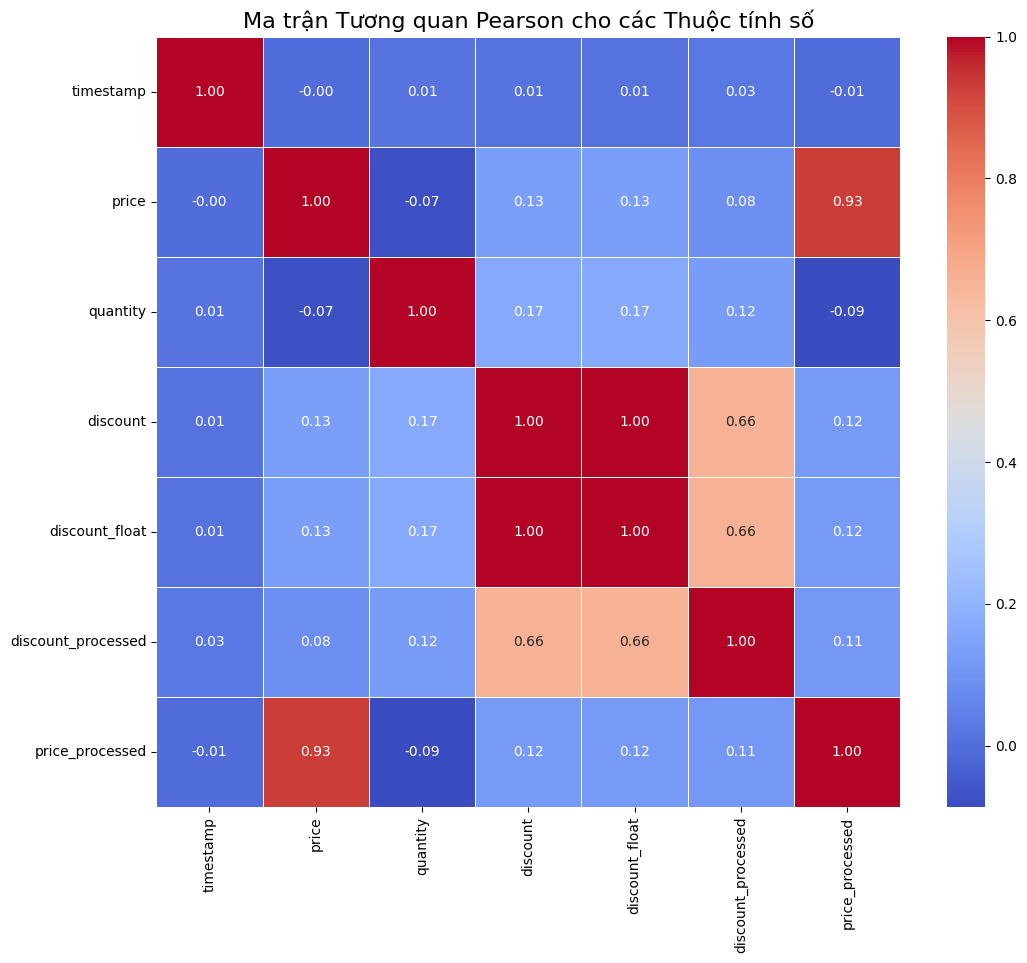

Các cặp thuộc tính số có tương quan cao (> 0.8):
       col1             col2      corr
0  discount   discount_float  1.000000
1     price  price_processed  0.931259


In [50]:
pearson_heatmap(purchase_history, num_cols, cat_cols)

#### Các biến số `discount` – `discount_float` và `price` – `price_processed` có tương quan rất cao (≥ 0.93), nghĩa là chúng gần như biểu diễn cùng một thông tin
##### Giữ `discount_float` thay cho `discount` (vì đã ở dạng số sẵn)
##### Giữ `price_processed` thay cho `price` (vì là phiên bản đã chuẩn hóa)

In [51]:
remove = ['discount', 'price']
purchase_history = purchase_history.drop(remove)
num_cols = [num_col for num_col in num_cols if num_col not in remove]

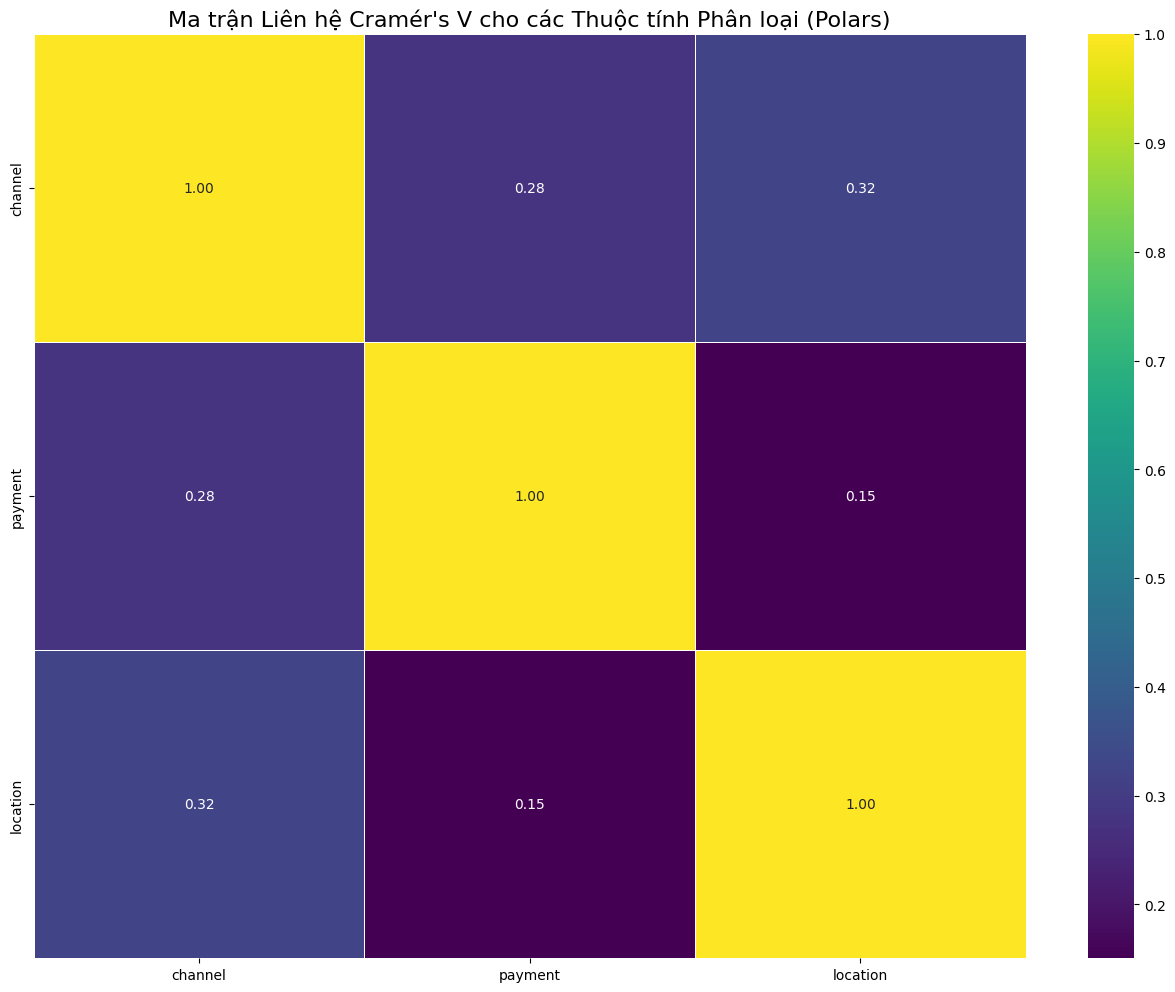

Các cặp thuộc tính phân loại có liên hệ mạnh (> 0.7):
Không có


In [52]:
cramers_v_heatmap(purchase_history, num_cols, cat_cols)

#### Vì số bản ghi trong Purchase History quá lớn nên chúng em sử dụng phương pháp sampling trên 10.000.000 mẫu


CÁC CẶP FEATURE CÓ η² > 0.7:
Không có cặp nào có η² > 0.7


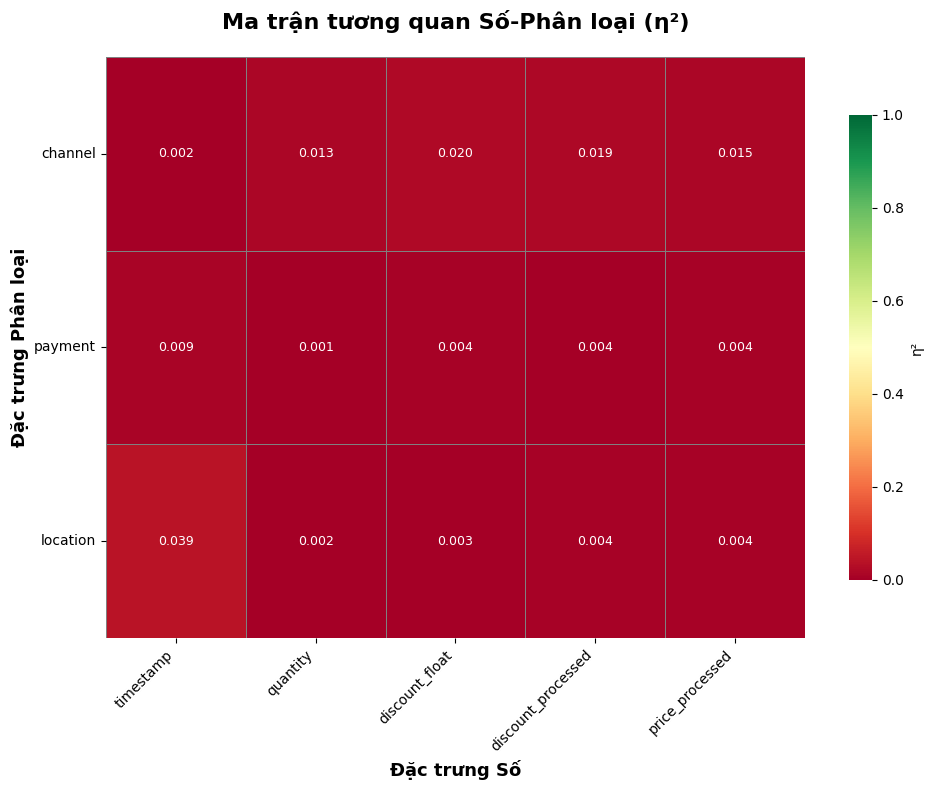

In [53]:
compute_correlation_ratio_matrix(
    purchase_history, 
    num_cols, 
    cat_cols,
    sample_size=10_000_000
)

## Task 4: Chuẩn hoá và biến đổi dữ liệu

### Chuẩn hóa và biến đổi bảng Users

In [54]:
print(user.columns)

['customer_id', 'gender', 'province', 'membership', 'timestamp', 'install_app']


In [55]:
def transform_users(user_df: pl.DataFrame) -> pl.DataFrame:
    df = user_df.clone()
    initial_shape = df.shape
    
    # ----- 4.1.1. CHUẨN HÓA TEMPORAL FEATURES -----
    print("\n[4.1.1] Chuẩn hóa đặc trưng thời gian")

    df = df.with_columns([
        pl.from_epoch(pl.col("timestamp"), time_unit="s").alias("account_created_at"),
        pl.from_epoch(pl.col("timestamp"), time_unit="s").dt.year().alias("created_year"),
        pl.from_epoch(pl.col("timestamp"), time_unit="s").dt.quarter().alias("created_quarter"),
        pl.from_epoch(pl.col("timestamp"), time_unit="s").dt.month().alias("created_month"),
        pl.from_epoch(pl.col("timestamp"), time_unit="s").dt.weekday().alias("created_day_of_week"),
    ])

    # Tính account age (days)
    current_time = datetime.now()
    df = df.with_columns([
        ((pl.lit(current_time) - pl.col("account_created_at")).dt.total_days())
        .alias("account_age_days")
    ])
    print("   ✅ Tạo thêm các đặc trưng thời gian: created_year, created_quarter, account_age_days")
    
    # ----- 4.1.2. ENCODING CATEGORICAL FEATURES -----
    print("\n[4.1.2] Encode đặc trưng phân loại")

    # Gender encoding (cast Int8 để gọn bộ nhớ)
    df = df.with_columns([
        pl.when(pl.col("gender") == "Nam").then(pl.lit(1))
         .when(pl.col("gender") == "Nữ").then(pl.lit(0))
         .otherwise(pl.lit(None))
         .cast(pl.Int8)
         .alias("gender_encoded")
    ])

    # Membership ordinal encoding (bao phủ nhiều hạng hơn)
    membership_order = {
        "Standard": 0, "Silver": 1, "Gold": 2, "Premium": 3,
        "Platinum": 4, "VIP": 4  # nếu có
    }
    df = df.with_columns([
        pl.col("membership").replace_strict(membership_order, default=0).cast(pl.Int8).alias("membership_tier")
    ])

    # App installation binary
    df = df.with_columns([
        (pl.col("install_app") != "In-Store").cast(pl.Int8).alias("has_app")
    ])
    print("   ✅ Encoded: gender (nhị phân), membership (thứ bậc), install_app (nhị phân)")
    
    # >>> BỔ SUNG: Cờ premium phục vụ segmentation (Gold trở lên coi là premium)
    df = df.with_columns([
        (pl.col("membership_tier") >= 2).cast(pl.Int8).alias("is_premium_tier")
    ])

    # ----- 4.1.3. GEOGRAPHIC ENCODING -----
    print("\n[4.1.3] Encode đặc trưng địa lý")

    # Binary flags cho major cities
    df = df.with_columns([
        (pl.col("province") == "Hồ Chí Minh").cast(pl.Int8).alias("is_hcm"),
        (pl.col("province").is_in(["Hồ Chí Minh", "Hà Nội", "Đà Nẵng"]))
        .cast(pl.Int8).alias("is_major_city")
    ])

    # Frequency encoding cho province
    province_counts = df.group_by("province").agg(pl.len().alias("province_user_count"))
    df = df.join(province_counts, on="province", how="left")
    print("   ✅ Geographic encoding: is_hcm, is_major_city, province_user_count")
    
    # ----- 4.1.4. NORMALIZATION (MIN-MAX SCALING) -----
    print("\n[4.1.4] Chuẩn hoá Min-Max")

    num_features = ["account_age_days", "province_user_count"]
    for col in num_features:
        if col in df.columns:
            col_min = df[col].min()
            col_max = df[col].max()
            col_range = col_max - col_min
            if (col_range is not None) and (col_range > 0):
                df = df.with_columns([
                    ((pl.col(col) - col_min) / col_range).alias(f"{col}_norm")
                ])
    print(f"   ✅ Normalized: {', '.join([f'{c}_norm' for c in num_features])}")
    
    # ----- 4.1.5. DROP REDUNDANT COLUMNS -----
    print("\n[4.1.5] Xoá các cột dư thừa")
    cols_to_drop = [
        "timestamp",           # Đã extract features
        "account_created_at",  # Temporary column
        "gender",              # Đã encode thành gender_encoded
        "membership",          # Đã encode thành membership_tier / is_premium_tier
        "install_app",         # Đã encode thành has_app
    ]
    df = df.drop([c for c in cols_to_drop if c in df.columns])
    print(f"   ✅ Đã xoá {len([c for c in cols_to_drop if c in user_df.columns])} cột dư thừa")
    
    # ----- SUMMARY -----
    final_shape = df.shape
    print(f"\n{'='*80}")
    print(f"   Input:  {initial_shape[0]:,} rows × {initial_shape[1]} cols")
    print(f"   Output: {final_shape[0]:,} rows × {final_shape[1]} cols")
    print(f"{'='*80}\n")
    return df


In [56]:
user = transform_users(user)
user


[4.1.1] Chuẩn hóa đặc trưng thời gian
   ✅ Tạo thêm các đặc trưng thời gian: created_year, created_quarter, account_age_days

[4.1.2] Encode đặc trưng phân loại
   ✅ Encoded: gender (nhị phân), membership (thứ bậc), install_app (nhị phân)

[4.1.3] Encode đặc trưng địa lý
   ✅ Geographic encoding: is_hcm, is_major_city, province_user_count

[4.1.4] Chuẩn hoá Min-Max
   ✅ Normalized: account_age_days_norm, province_user_count_norm

[4.1.5] Xoá các cột dư thừa
   ✅ Đã xoá 4 cột dư thừa

   Input:  4,573,964 rows × 6 cols
   Output: 4,573,964 rows × 16 cols



customer_id,province,created_year,created_quarter,created_month,created_day_of_week,account_age_days,gender_encoded,membership_tier,has_app,is_premium_tier,is_hcm,is_major_city,province_user_count,account_age_days_norm,province_user_count_norm
i32,str,i32,i8,i8,i8,i64,i8,i8,i8,i8,i8,i8,u32,f64,f64
14732,"""Hồ Chí Minh""",2011,2,5,3,5270,1,0,0,0,1,1,1223333,1.0,1.0
15126,"""Hồ Chí Minh""",2011,2,5,3,5270,0,0,0,0,1,1,1223333,1.0,1.0
29718,"""Bến Tre""",2011,3,7,7,5204,0,0,0,0,0,0,43395,0.987409,0.035472
30077,"""Hồ Chí Minh""",2011,3,8,4,5178,0,0,0,0,1,1,1223333,0.982449,1.0
30085,"""Hồ Chí Minh""",2011,3,8,4,5178,0,0,0,0,1,1,1223333,0.982449,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
8800478,"""Đồng Nai""",2025,2,6,7,136,0,0,0,0,0,0,312131,0.020603,0.255147
8814340,"""Long An""",2025,2,6,4,132,0,0,0,0,0,0,133752,0.01984,0.109333
8810998,"""Bạc Liêu""",2025,2,6,3,133,1,0,0,0,0,0,29801,0.020031,0.02436


In [57]:
def transform_items(item_df):
    df = item_df.clone()
    initial_shape = df.shape
    
    # ----- 4.2.1. PRICE HANDLING (ITEMS) -----
    print("\n[4.2.1] Price Processing")
    
    # Note: price in items is object type, need to clean first
    # Assuming price is already processed to numeric in previous steps
    # If not, we need to clean it first:
    df = df.with_columns([
        pl.col("price").cast(pl.Float64, strict=False).alias("price_numeric")
    ])
    
    # Log transformation để giảm skewness
    df = df.with_columns([
        pl.when(pl.col("price_numeric") > 0)
        .then(pl.col("price_numeric").log())
        .otherwise(0)
        .alias("price_log"),
        
        # Min-Max normalization
        ((pl.col("price_numeric") - pl.col("price_numeric").min()) / 
         (pl.col("price_numeric").max() - pl.col("price_numeric").min()))
        .alias("price_norm")
    ])
    
    # Price binning (segmentation) - for Vietnamese retail
    df = df.with_columns([
        pl.when(pl.col("price_numeric") < 50000).then(pl.lit("Low"))
        .when(pl.col("price_numeric") < 200000).then(pl.lit("Medium"))
        .when(pl.col("price_numeric") < 500000).then(pl.lit("High"))
        .otherwise(pl.lit("Premium"))
        .alias("price_segment")
    ])
    
    print(f"   ✅ Đặc trưng Price: price_log, price_norm, price_segment")
    
    # ----- 4.2.2. CATEGORY ENCODING -----
    print("\n[4.2.2] Encode Category")
    
    # Frequency encoding cho category_id (thay vì one-hot vì high cardinality)
    category_counts = df.group_by("category_id").agg(
        pl.len().alias("category_item_count")
    )
    df = df.join(category_counts, on="category_id", how="left")
    
    print(f"   ✅ Encode tần suất category hoàn thành")
    
    # ----- 4.2.3. BRAND ENCODING -----
    print("\n[4.2.3] Encode Brand")
    
    # Top brands vs Others
    brand_counts = df.group_by("brand").agg(pl.len().alias("brand_count"))
    top_brands = brand_counts.sort("brand_count", descending=True).head(20)["brand"].to_list()
    
    df = df.with_columns([
        pl.col("brand").is_in(top_brands).cast(pl.Int8).alias("is_top_brand")
    ])
    
    # Brand frequency
    df = df.join(
        brand_counts.rename({"brand_count": "brand_item_count"}),
        on="brand",
        how="left"
    )
    
    print(f"   ✅ Encode Brand: is_top_brand, brand_item_count")
    
    # ----- 4.2.4. TEXT FEATURES (BASIC) -----
    print("\n[4.2.4] Basic Text Features")
    
    df = df.with_columns([
        # Description length (indicator of detail)
        pl.col("description").str.len_chars().alias("description_length"),
        
        # Has detailed description
        (pl.col("description").str.len_chars() > 100).cast(pl.Int8).alias("has_detailed_desc"),
        
        # Has new description
        pl.col("description_new").is_not_null().cast(pl.Int8).alias("has_new_desc")
    ])
    
    print(f"   ✅ Đặc trưng text: description_length, has_detailed_desc")
    
    # ----- 4.2.5. PRODUCT ATTRIBUTES -----
    print("\n[4.2.5] Encode thuộc tính sản phẩm")
    
    # Target demographic
    df = df.with_columns([
        (pl.col("gender_target") == "Unisex").cast(pl.Int8).alias("is_unisex"),
        (pl.col("age_group") == "Adult").cast(pl.Int8).alias("is_adult_target"),
    ])
    
    # Sale status
    df = df.with_columns([
        pl.col("sale_status").cast(pl.Int8).alias("is_on_sale")
    ])
    
    print(f"   ✅ Đã encode thuộc tính sản phẩm")
    
    # ----- 4.2.6. DROP REDUNDANT -----
    print("\n[4.2.6] Loại bỏ các cột dư thừa")
    
    cols_to_drop = [
        "description",  # Đã extract length
        "description_new",  # Đã check existence
        "gender_target",  # Đã encode
        "age_group",  # Đã encode
        "sale_status",  # Đã encode
    ]
    
    df = df.drop([c for c in cols_to_drop if c in df.columns])
    
    # ----- SUMMARY -----
    final_shape = df.shape
    print(f"\n{'='*80}")
    print(f"   Input:  {initial_shape[0]:,} rows × {initial_shape[1]} cols")
    print(f"   Output: {final_shape[0]:,} rows × {final_shape[1]} cols")
    print(f"   Đặc trưng mới: {final_shape[1] - initial_shape[1] + len(cols_to_drop)}")
    print(f"{'='*80}\n")
    
    return df


In [58]:
item = transform_items(item)
item


[4.2.1] Price Processing
   ✅ Đặc trưng Price: price_log, price_norm, price_segment

[4.2.2] Encode Category
   ✅ Encode tần suất category hoàn thành

[4.2.3] Encode Brand
   ✅ Encode Brand: is_top_brand, brand_item_count

[4.2.4] Basic Text Features
   ✅ Đặc trưng text: description_length, has_detailed_desc

[4.2.5] Encode thuộc tính sản phẩm
   ✅ Đã encode thuộc tính sản phẩm

[4.2.6] Loại bỏ các cột dư thừa

   Input:  27,332 rows × 17 cols
   Output: 27,332 rows × 25 cols
   Đặc trưng mới: 13



item_id,price,category_id,brand,manufacturer,creation_timestamp,item_type,color,size,origin,volume,material,price_numeric,price_log,price_norm,price_segment,category_item_count,is_top_brand,brand_item_count,description_length,has_detailed_desc,has_new_desc,is_unisex,is_adult_target,is_on_sale
str,"decimal[38,4]",i32,str,str,i64,str,str,str,str,str,str,f64,f64,f64,str,u32,i8,u32,u32,i8,i8,i8,i8,i8
"""0502020000004""",99000.0000,7058,"""Dr.Brown's""","""Không xác định""",1333531544,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",99000.0,11.502875,0.004717,"""Medium""",15,0,27,14,0,1,0,0,0
"""0010290040150""",69000.0000,6987,"""Con Cưng""","""Không xác định""",1503046250,"""Bộ quần áo""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",69000.0,11.141862,0.003287,"""Medium""",741,1,484,14,0,1,0,0,0
"""0008010000015""",45000.0000,2121,"""Thương hiệu khác""","""Không xác định""",1358501584,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",45000.0,10.714418,0.002144,"""Low""",12,1,607,607,1,1,0,0,0
"""0020010000094""",401000.0000,2276,"""Merries Nhật""","""Không xác định""",1400062039,"""Không xác định""","""Không xác định""","""Không xác định""","""Nhật Bản, Nhật Bản""","""Không xác định""","""Giấy, bột giấy, vải không dệt,…",401000.0,12.901717,0.019104,"""High""",7,0,39,1306,1,1,0,0,0
"""0020010000098""",401000.0000,2278,"""Merries Nhật""","""Không xác định""",1400062040,"""Không xác định""","""Không xác định""","""Không xác định""","""Nhật Bản, Nhật Bản""","""Không xác định""","""Giấy, bột giấy, vải không dệt,…",401000.0,12.901717,0.019104,"""High""",26,0,39,1113,1,1,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""3389000000238""",129000.0000,3389,"""Animo""","""Không xác định""",1740043302,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",129000.0,11.767568,0.006146,"""Medium""",140,1,8149,14,0,1,0,0,1
"""3389000000212""",129000.0000,3389,"""Animo""","""Không xác định""",1740043302,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",129000.0,11.767568,0.006146,"""Medium""",140,1,8149,14,0,1,0,0,1
"""3389000000213""",129000.0000,3389,"""Animo""","""Không xác định""",1740043302,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",129000.0,11.767568,0.006146,"""Medium""",140,1,8149,14,0,1,0,0,1


In [59]:
def transform_purchase(purchase_df):
    df = purchase_df.clone()
    initial_shape = df.shape
    
    # ----- 4.3.1. TEMPORAL FEATURES -----
    print("\n[4.3.1] Đặc trưng thời gian")
    
    df = df.with_columns([
        pl.from_epoch("timestamp", time_unit="s").alias("purchase_datetime"),
    ])
    
    df = df.with_columns([
        pl.col("purchase_datetime").dt.year().alias("purchase_year"),
        pl.col("purchase_datetime").dt.quarter().alias("purchase_quarter"),
        pl.col("purchase_datetime").dt.month().alias("purchase_month"),
        pl.col("purchase_datetime").dt.weekday().alias("purchase_dow"),
        pl.col("purchase_datetime").dt.hour().alias("purchase_hour"),
    ])
    
    # Time of day segmentation
    df = df.with_columns([
        pl.when(pl.col("purchase_hour").is_between(6, 12)).then(pl.lit("Morning"))
        .when(pl.col("purchase_hour").is_between(12, 18)).then(pl.lit("Afternoon"))
        .when(pl.col("purchase_hour").is_between(18, 22)).then(pl.lit("Evening"))
        .otherwise(pl.lit("Night"))
        .alias("time_of_day")
    ])
    
    print(f"   ✅ Đã phân giải đặc trưng thời gia")
    
    # ----- 4.3.2. TRANSACTION AMOUNT FEATURES -----
    print("\n[4.3.2] Đặc trưng số lượng giao dịch")
    
    # Total transaction amount
    df = df.with_columns([
        (pl.col("price_processed") * pl.col("quantity")).alias("transaction_amount"),
        
        # Discount ratio
        (pl.col("discount_float") / pl.col("price_processed")).fill_nan(0).alias("discount_rate"),
        
        # Final amount after discount
        ((pl.col("price_processed") * pl.col("quantity")) - pl.col("discount_float"))
        .alias("final_amount")
    ])
    
    # Log transformation
    df = df.with_columns([
        pl.when(pl.col("final_amount") > 0)
        .then(pl.col("final_amount").log())
        .otherwise(0)
        .alias("final_amount_log")
    ])
    
    print(f"   ✅ Đặc trưng số lượng giao dịch: transaction_amount, discount_rate, final_amount")
    
    # ----- 4.3.3. CHANNEL & PAYMENT ENCODING -----
    print("\n[4.3.3] Encode channel và payment")
    
    # Binary flags
    df = df.with_columns([
        (pl.col("channel") == "In-Store").cast(pl.Int8).alias("is_instore"),
        (pl.col("channel") == "Online").cast(pl.Int8).alias("is_online"),
        (pl.col("payment") == "Tiền mặt").cast(pl.Int8).alias("is_cash"),
        (pl.col("discount_float") > 0).cast(pl.Int8).alias("has_discount"),
    ])
    
    # Frequency encoding
    channel_freq = df.group_by("channel").agg(pl.len().alias("channel_freq"))
    payment_freq = df.group_by("payment").agg(pl.len().alias("payment_freq"))
    
    df = df.join(channel_freq, on="channel", how="left")
    df = df.join(payment_freq, on="payment", how="left")
    
    print(f"   ✅ Channel & payment encoded")
    
    # ----- 4.3.4. NORMALIZE NUMERICAL -----
    print("\n[4.3.4] Chuẩn hoá đặc trưng số")
    
    num_cols = ["transaction_amount", "final_amount", "quantity"]
    
    for col in num_cols:
        if col in df.columns:
            col_min = df[col].min()
            col_max = df[col].max()
            col_range = col_max - col_min
            
            if col_range > 0:
                df = df.with_columns([
                    ((pl.col(col) - col_min) / col_range).alias(f"{col}_norm")
                ])
    
    print(f"   ✅ Đã chuẩn hoá: {', '.join(num_cols)}")
    
    # ----- 4.3.5. DROP REDUNDANT -----
    print("\n[4.3.5] Xoá các cột dư thừa")
    
    cols_to_drop = [
        "timestamp",  # Đã convert sang datetime
        "purchase_datetime",  # Đã extract features
        "channel",  # Đã encode
        "payment",  # Đã encode
        "price_processed",  # Đã tính transaction_amount
        "discount_float",  # Đã tính discount_rate
    ]
    
    df = df.drop([c for c in cols_to_drop if c in df.columns])
    
    # ----- SUMMARY -----
    final_shape = df.shape
    print(f"\n{'='*80}")
    print(f"   Input:  {initial_shape[0]:,} rows × {initial_shape[1]} cols")
    print(f"   Output: {final_shape[0]:,} rows × {final_shape[1]} cols")
    print(f"   New features created: {final_shape[1] - initial_shape[1] + len(cols_to_drop)}")
    print(f"{'='*80}\n")
    
    return df

In [60]:
purchase_history = transform_purchase(purchase_history)
purchase_history


[4.3.1] Đặc trưng thời gian
   ✅ Đã phân giải đặc trưng thời gia

[4.3.2] Đặc trưng số lượng giao dịch
   ✅ Đặc trưng số lượng giao dịch: transaction_amount, discount_rate, final_amount

[4.3.3] Encode channel và payment
   ✅ Channel & payment encoded

[4.3.4] Chuẩn hoá đặc trưng số
   ✅ Đã chuẩn hoá: transaction_amount, final_amount, quantity

[4.3.5] Xoá các cột dư thừa

   Input:  35,729,825 rows × 10 cols
   Output: 35,729,825 rows × 24 cols
   New features created: 20



item_id,quantity,customer_id,location,discount_processed,purchase_year,purchase_quarter,purchase_month,purchase_dow,purchase_hour,time_of_day,transaction_amount,discount_rate,final_amount,final_amount_log,is_instore,is_online,is_cash,has_discount,channel_freq,payment_freq,transaction_amount_norm,final_amount_norm,quantity_norm
str,i32,i32,i32,f64,i32,i8,i8,i8,i8,str,f64,f64,f64,f64,i8,i8,i8,i8,u32,u32,f64,f64,f64
"""7115000000004""",1,5254214,656,0.0,2024,4,12,2,18,"""Afternoon""",49000.0,0.0,49000.0,10.799576,1,0,0,0,33016358,5766946,0.001823,0.218633,0.0
"""0029130000030""",1,7573232,143,0.0,2024,4,12,2,19,"""Evening""",69000.0,0.0,69000.0,11.141862,1,0,1,0,33016358,22454572,0.002567,0.219215,0.0
"""3496000000053""",2,8187418,213,0.0,2024,4,12,2,19,"""Evening""",150000.0,0.0,150000.0,11.918391,1,0,0,0,33016358,747996,0.005581,0.221574,0.004184
"""2700000000002""",2,8187418,213,13000.0,2024,4,12,2,19,"""Evening""",117000.0,0.222222,104000.0,11.552146,1,0,0,1,33016358,747996,0.004353,0.220234,0.004184
"""0029110000036""",1,6931560,590,10000.0,2024,4,12,6,9,"""Morning""",89000.0,0.11236,79000.0,11.277203,0,0,0,1,483885,747996,0.003311,0.219506,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""1396000000020""",1,6848354,446,4950.0,2024,4,10,5,16,"""Afternoon""",28050.0,0.176471,23100.0,10.047588,1,0,1,1,33016358,22454572,0.001044,0.217878,0.0
"""0007070000403""",1,5745481,228,0.0,2024,4,10,6,13,"""Afternoon""",189000.0,0.0,189000.0,12.149502,0,0,1,0,1397128,22454572,0.007032,0.22271,0.0
"""4371000000001""",1,3307869,368,0.0,2024,4,10,6,10,"""Morning""",59000.0,0.0,59000.0,10.985293,1,0,1,0,33016358,22454572,0.002195,0.218924,0.0


## Task 5: Rút trích thêm đặc trưng

## 1. RFM Features (Recency - Frequency - Monetary)

Giúp dự đoán hành vi mua hàng trong tương lai:

- **Recency (Gần đây nhất):** Bao lâu kể từ lần mua cuối cùng → Càng gần thì khả năng mua lại càng cao

- **Frequency (Tần suất):** Số lần mua hàng trong một khoảng thời gian → Mua thường xuyên khả năng là khách trung thành

- **Monetary (Giá trị tiền tệ):** Tổng chi tiêu của khách hàng → Chi tiêu cao chứng tỏ khách hàng giá trị


In [61]:
def create_rfm_features(purchase_df, reference_date=None):
    if reference_date is None:
        reference_date = datetime.now()
    
    print(f"[THÔNG TIN] Ngày tham chiếu: {reference_date}")
    
    # ----- RECENCY: Số ngày kể từ lần mua gần nhất -----
    print("\n[5.1.1] Tính toán RECENCY (độ mới của lần mua)...")
    
    recency = purchase_df.group_by("customer_id").agg([
        pl.col("purchase_year").max().alias("last_purchase_year"),
        pl.col("purchase_month").max().alias("last_purchase_month"),
    ])
    
    # Tính số ngày kể từ lần mua cuối (ước lượng theo năm & tháng)
    recency = recency.with_columns([
        (
            (reference_date.year - pl.col("last_purchase_year")) * 365 +
            (reference_date.month - pl.col("last_purchase_month")) * 30
        ).alias("recency_days")
    ])
    
    print(f"   ✅ Đã tính Recency cho {recency.shape[0]:,} khách hàng")
    
    # ----- FREQUENCY: Số lần mua hàng -----
    print("\n[5.1.2] Tính toán FREQUENCY (tần suất mua)...")
    
    frequency = purchase_df.group_by("customer_id").agg([
        pl.len().alias("purchase_count"),
        pl.col("quantity").sum().alias("total_items_bought"),
        pl.col("item_id").n_unique().alias("unique_products_bought"),
    ])
    
    # Các chỉ số phụ về tần suất mua hàng
    frequency = frequency.with_columns([
        (pl.col("total_items_bought") / pl.col("purchase_count")).alias("avg_items_per_transaction"),
    ])
    
    print(f"   ✅ Đã tính Frequency: purchase_count, total_items_bought, unique_products_bought")
    
    # ----- MONETARY: Tổng chi tiêu -----
    print("\n[5.1.3] Tính toán MONETARY (giá trị chi tiêu)...")
    
    monetary = purchase_df.group_by("customer_id").agg([
        pl.col("final_amount").sum().alias("total_spent"),
        pl.col("final_amount").mean().alias("avg_transaction_value"),
        pl.col("final_amount").max().alias("max_transaction_value"),
        pl.col("discount_rate").mean().alias("avg_discount_rate"),
    ])
    
    print(f"   ✅ Đã tính Monetary: total_spent, avg_transaction_value, max_transaction_value")
    
    # ----- GHÉP 3 BẢNG RFM -----
    rfm = recency.join(frequency, on="customer_id", how="full", suffix="_freq")
    rfm = rfm.join(monetary, on="customer_id", how="full", suffix="_mon")

    
    # ----- RFM SCORES (1-5) -----
    print("\n[5.1.4] Tạo điểm RFM (RFM Scores)...")
    
    rfm = rfm.with_columns([
        # Điểm Recency (mua càng gần đây → điểm càng cao)
        pl.col("recency_days").qcut(5, labels=["5", "4", "3", "2", "1"]).alias("R_score"),
        
        # Điểm Frequency (mua càng thường xuyên → điểm càng cao)
        pl.col("purchase_count").qcut(5, labels=["1", "2", "3", "4", "5"], allow_duplicates=True).alias("F_score"),
        
        # Điểm Monetary (chi tiêu càng nhiều → điểm càng cao)
        pl.col("total_spent").qcut(5, labels=["1", "2", "3", "4", "5"], allow_duplicates=True).alias("M_score"),
    ])
    
    # Tổng hợp điểm RFM
    rfm = rfm.with_columns([
        (pl.col("R_score").cast(pl.Int8) + 
         pl.col("F_score").cast(pl.Int8) + 
         pl.col("M_score").cast(pl.Int8)).alias("rfm_score")
    ])
    
    print(f"   ✅ Đã tạo điểm RFM (thang 1–5)")
    print(f"\n{'='*80}")
    print(f"✅ Hoàn thành RFM Features: {rfm.shape[1]} đặc trưng cho {rfm.shape[0]:,} khách hàng")
    print(f"{'='*80}\n")
    
    return rfm

In [62]:
rfm_features = create_rfm_features(purchase_history)

[THÔNG TIN] Ngày tham chiếu: 2025-10-29 18:21:08.226081

[5.1.1] Tính toán RECENCY (độ mới của lần mua)...
   ✅ Đã tính Recency cho 2,442,306 khách hàng

[5.1.2] Tính toán FREQUENCY (tần suất mua)...
   ✅ Đã tính Frequency: purchase_count, total_items_bought, unique_products_bought

[5.1.3] Tính toán MONETARY (giá trị chi tiêu)...
   ✅ Đã tính Monetary: total_spent, avg_transaction_value, max_transaction_value

[5.1.4] Tạo điểm RFM (RFM Scores)...
   ✅ Đã tạo điểm RFM (thang 1–5)

✅ Hoàn thành RFM Features: 18 đặc trưng cho 2,442,306 khách hàng



## 2. Đặc trưng Hành vi (Behavioral Pattern Features)

Phát hiện thói quen mua sắm của khách hàng:

- Giờ nào, ngày nào trong tuần, hoặc tháng nào khách hàng thường mua sắm

- Khách hàng thích mua online hay offline hơn

- Tốc độ mua hàng tăng hay giảm theo thời gian

- Mức độ quan tâm và phản ứng với các chương trình giảm giá hoặc khuyến mãi


In [63]:
def create_behavioral_features(purchase_df: pl.DataFrame) -> pl.DataFrame:
    # ---------- 5.2.1 TIME PATTERNS ----------
    print("[5.2.1] Phân tích thói quen mua theo thời gian...")

    # tổng lượt mua / KH để làm mẫu số chuẩn
    txn_counts = (
        purchase_df.group_by("customer_id")
        .agg(pl.len().alias("total_purchases"))
    )

    time_patterns = purchase_df.group_by("customer_id").agg([
        pl.col("time_of_day").mode().first().alias("preferred_time"),
        (pl.col("time_of_day") == "Morning").sum().alias("morning_purchases"),
        (pl.col("time_of_day") == "Evening").sum().alias("evening_purchases"),
        pl.col("purchase_dow").mode().first().alias("preferred_dow"),
        (pl.col("purchase_dow").is_in([6, 7])).sum().alias("weekend_purchases"),
        pl.col("purchase_month").mode().first().alias("preferred_month"),
        (pl.col("purchase_month").is_in([11, 12])).sum().alias("holiday_season_purchases"),
    ]).join(txn_counts, on="customer_id", how="left")

    # Tỉ lệ cuối tuần = weekend / tổng
    time_patterns = time_patterns.with_columns([
        pl.when(pl.col("total_purchases") > 0)
          .then(pl.col("weekend_purchases") / pl.col("total_purchases"))
          .otherwise(0.0)
          .alias("weekend_purchase_ratio")
    ])

    print("   ✅ Đặc trưng thời gian: preferred_time, preferred_dow, preferred_month, weekend_purchase_ratio")

    # ---------- 5.2.2 CHANNEL & PAYMENT ----------
    print("\n[5.2.2] Phân tích kênh mua và thanh toán...")

    channel_patterns = purchase_df.group_by("customer_id").agg([
        pl.col("is_online").sum().alias("online_purchases"),
        pl.col("is_instore").sum().alias("instore_purchases"),
        pl.col("is_cash").sum().alias("cash_payments"),
        pl.col("has_discount").sum().alias("purchases_with_discount"),
    ]).join(txn_counts, on="customer_id", how="left")

    channel_patterns = channel_patterns.with_columns([
        pl.when((pl.col("online_purchases") + pl.col("instore_purchases")) > 0)
          .then(pl.col("online_purchases") / (pl.col("online_purchases") + pl.col("instore_purchases")))
          .otherwise(0.0)
          .alias("online_preference"),

        pl.when(pl.col("total_purchases") > 0)
          .then(pl.col("purchases_with_discount") / pl.col("total_purchases"))
          .otherwise(0.0)
          .alias("discount_seeker_score"),
    ])

    print("   ✅ Đặc trưng kênh: online_preference, discount_seeker_score")

    # ---------- 5.2.3 VELOCITY & STABILITY ----------
    print("\n[5.2.3] Phân tích tốc độ và độ ổn định mua hàng...")

    # lifespan theo năm dựa trên year min/max
    lifespan = purchase_df.group_by("customer_id").agg([
        (pl.col("purchase_year").max() - pl.col("purchase_year").min()).alias("customer_lifespan_years"),
        pl.col("final_amount").std().alias("purchase_amount_std"),
        pl.col("quantity").std().alias("quantity_std"),
    ]).join(txn_counts, on="customer_id", how="left")

    # Purchases per year = total_purchases / max(lifespan_years, 1)
    lifespan = lifespan.with_columns([
        pl.when(pl.col("customer_lifespan_years") > 0)
          .then(pl.col("total_purchases") / pl.col("customer_lifespan_years"))
          .otherwise(pl.col("total_purchases").cast(pl.Float64))  # toàn bộ trong 1 năm
          .alias("purchases_per_year")
    ])

    print("   ✅ Đặc trưng tốc độ: purchases_per_year; độ ổn định: purchase_amount_std, quantity_std")

    # ---------- JOIN ALL ----------
    behavioral = (
        time_patterns.join(channel_patterns, on="customer_id", how="full", suffix="_ch")
                     .join(lifespan, on="customer_id", how="full", suffix="_vel")
    )

    print(f"\n{'='*80}")
    print(f"✅ Hoàn thành Behavioral Features: {behavioral.shape[1]} đặc trưng")
    print(f"{'='*80}\n")

    return behavioral


In [64]:
behavioral_features = create_behavioral_features(purchase_history)

[5.2.1] Phân tích thói quen mua theo thời gian...
   ✅ Đặc trưng thời gian: preferred_time, preferred_dow, preferred_month, weekend_purchase_ratio

[5.2.2] Phân tích kênh mua và thanh toán...
   ✅ Đặc trưng kênh: online_preference, discount_seeker_score

[5.2.3] Phân tích tốc độ và độ ổn định mua hàng...
   ✅ Đặc trưng tốc độ: purchases_per_year; độ ổn định: purchase_amount_std, quantity_std

✅ Hoàn thành Behavioral Features: 24 đặc trưng



## 3. Đặc trưng về sở thích sản phẩm (Product Affinity Features) 

Hiểu rõ sở thích và xu hướng tiêu dùng của khách hàng:

- Khách hàng mua nhiều hay ít loại danh mục sản phẩm khác nhau

- Mức độ trung thành với một thương hiệu cụ thể

- Khách hàng có xu hướng chọn hàng cao cấp hay bình dân

- Những sản phẩm hoặc thương hiệu được mua thường xuyên nhất

In [65]:
def create_product_affinity_features(purchase_df: pl.DataFrame, items_df: pl.DataFrame) -> pl.DataFrame:
    # 0) Tổng lượt mua / KH để dùng làm mẫu số chuẩn
    txn_counts = (
        purchase_df.group_by("customer_id")
        .agg(pl.len().alias("total_purchases"))
    )

    # 1) Chuẩn hoá giá & phân khúc giá trong items
    items_clean = (
        items_df.with_columns([
            pl.col("price").cast(pl.Float64, strict=False).alias("price_numeric")
        ])
        .with_columns([
            pl.when(pl.col("price_numeric") < 50_000).then(pl.lit("Thấp"))
            .when(pl.col("price_numeric") < 200_000).then(pl.lit("Trung bình"))
            .when(pl.col("price_numeric") < 500_000).then(pl.lit("Cao"))
            .otherwise(pl.lit("Cao cấp"))
            .alias("price_segment")
        ])
    )

    # Top brand
    brand_counts = items_clean.group_by("brand").agg(pl.len().alias("brand_count"))
    top_brands = (
        brand_counts.sort("brand_count", descending=True)
        .head(20)["brand"].to_list()
    )
    items_clean = items_clean.with_columns([
        pl.col("brand").is_in(top_brands).cast(pl.Int8).alias("is_top_brand")
    ])

    # Join purchase với items
    purchase_with_items = purchase_df.join(
        items_clean.select(["item_id", "category_id", "brand", "price_segment", "is_top_brand"]),
        on="item_id",
        how="left"
    )

    # 2) Category affinity
    print("[5.3.1] Phân tích sở thích theo danh mục (Category Preferences)...")
    category_affinity = purchase_with_items.group_by("customer_id").agg([
        pl.col("category_id").n_unique().alias("unique_categories"),
        pl.col("category_id").mode().first().alias("favorite_category"),
        pl.len().alias("total_category_purchases"),
    ]).join(txn_counts, on="customer_id", how="left")

    category_affinity = category_affinity.with_columns([
        pl.when(pl.col("unique_categories") > 0)
          .then(1.0 / pl.col("unique_categories"))
          .otherwise(0.0)
          .alias("category_concentration")
    ])
    print("   ✅ Đặc trưng danh mục: unique_categories, favorite_category, category_concentration")

    # 3) Brand loyalty
    print("\n[5.3.2] Phân tích độ trung thành thương hiệu...")
    brand_affinity = purchase_with_items.group_by("customer_id").agg([
        pl.col("brand").n_unique().alias("unique_brands"),
        pl.col("brand").mode().first().alias("favorite_brand"),
        pl.col("is_top_brand").sum().alias("top_brand_purchases"),
    ]).join(txn_counts, on="customer_id", how="left")

    brand_affinity = brand_affinity.with_columns([
        pl.when(pl.col("unique_brands") > 0)
          .then(1.0 / pl.col("unique_brands"))
          .otherwise(0.0)
          .alias("brand_loyalty_score"),

        pl.when(pl.col("total_purchases") > 0)
          .then(pl.col("top_brand_purchases") / pl.col("total_purchases"))
          .otherwise(0.0)
          .alias("top_brand_preference"),
    ])
    print("   ✅ Đặc trưng thương hiệu: unique_brands, brand_loyalty_score, top_brand_preference")

    # 4) Price sensitivity
    print("\n[5.3.3] Phân tích độ nhạy cảm giá...")
    price_affinity = purchase_with_items.group_by("customer_id").agg([
        pl.col("price_segment").mode().first().alias("preferred_price_segment"),
        (pl.col("price_segment") == "Thấp").sum().alias("low_price_purchases"),
        (pl.col("price_segment") == "Cao cấp").sum().alias("premium_purchases"),
    ]).join(txn_counts, on="customer_id", how="left")

    price_affinity = price_affinity.with_columns([
        pl.when(pl.col("total_purchases") > 0)
          .then(pl.col("premium_purchases") / pl.col("total_purchases"))
          .otherwise(0.0)
          .alias("premium_buyer_score"),

        pl.when(pl.col("total_purchases") > 0)
          .then(pl.col("low_price_purchases") / pl.col("total_purchases"))
          .otherwise(0.0)
          .alias("budget_conscious_score"),
    ])
    print("   ✅ Đặc trưng giá: preferred_price_segment, premium_buyer_score, budget_conscious_score")

    # 5) Hợp nhất các khối đặc trưng
    affinity = (
        category_affinity.join(brand_affinity, on="customer_id", how="full", suffix="_brand")
                         .join(price_affinity.drop("total_purchases"), on="customer_id", how="full", suffix="_price")
    )

    print(f"\n{'='*80}")
    print(f"✅ Hoàn thành Product Affinity Features: {affinity.shape[1]} đặc trưng")
    print(f"{'='*80}\n")

    return affinity


In [66]:
affinity_features = create_product_affinity_features(purchase_history, item)

[5.3.1] Phân tích sở thích theo danh mục (Category Preferences)...
   ✅ Đặc trưng danh mục: unique_categories, favorite_category, category_concentration

[5.3.2] Phân tích độ trung thành thương hiệu...
   ✅ Đặc trưng thương hiệu: unique_brands, brand_loyalty_score, top_brand_preference

[5.3.3] Phân tích độ nhạy cảm giá...
   ✅ Đặc trưng giá: preferred_price_segment, premium_buyer_score, budget_conscious_score

✅ Hoàn thành Product Affinity Features: 19 đặc trưng



## 4. Đặc trưng Time-Series Features

Phân tích xu hướng và hành vi mua hàng theo thời gian:

- Tần suất mua tăng hay giảm qua các quý

- Mức chi tiêu tăng hay giảm theo thời gian

- So sánh mức độ mua sắm hiện tại với quá khứ → phát hiện sớm khách hàng rời bỏ

- Nhận diện mùa hoặc giai đoạn mua hàng cao điểm


In [67]:
def create_timeseries_features(purchase_df: pl.DataFrame) -> pl.DataFrame:
    # Base id
    base_ids = purchase_df.select(pl.col("customer_id")).unique()

    # ----- 5.4.1. XU HƯỚNG MUA HÀNG (PURCHASE TREND) -----
    print("[5.4.1] Phân tích xu hướng tần suất mua hàng...")

    purchase_periods = purchase_df.with_columns([
        (pl.col("purchase_year").cast(pl.Utf8) + pl.lit("-Q") + pl.col("purchase_quarter").cast(pl.Utf8))
        .alias("year_quarter")
    ])

    quarterly_purchases = purchase_periods.group_by(["customer_id", "year_quarter"]).agg(
        pl.len().alias("purchases_in_quarter")
    )

    trend = quarterly_purchases.group_by("customer_id").agg([
        pl.col("purchases_in_quarter").mean().alias("avg_quarterly_purchases"),
        pl.col("purchases_in_quarter").std().alias("quarterly_purchase_volatility"),
        pl.col("year_quarter").n_unique().alias("active_quarters"),
    ])

    print("   ✅ Đặc trưng xu hướng: avg_quarterly_purchases, quarterly_purchase_volatility, active_quarters")

    # ----- 5.4.2. XU HƯỚNG CHI TIÊU (SPENDING TREND) -----
    print("\n[5.4.2] Phân tích xu hướng chi tiêu theo thời gian...")

    quarterly_spending = purchase_periods.group_by(["customer_id", "year_quarter"]).agg(
        pl.col("final_amount").sum().alias("spending_in_quarter")
    )
    spending_trend = quarterly_spending.group_by("customer_id").agg([
        pl.col("spending_in_quarter").mean().alias("avg_quarterly_spending"),
        pl.col("spending_in_quarter").std().alias("spending_volatility"),
    ])

    print("   ✅ Đặc trưng chi tiêu: avg_quarterly_spending, spending_volatility")

    # ----- 5.4.3. HOẠT ĐỘNG GẦN ĐÂY (RECENT ACTIVITY) -----
    print("\n[5.4.3] Phân tích hoạt động mua hàng gần đây...")

    recent_activity = purchase_df.group_by("customer_id").agg([
        (pl.col("purchase_year") == pl.col("purchase_year").max()).sum().alias("purchases_last_year"),
        (
            (pl.col("purchase_year") == pl.col("purchase_year").max()) &
            (pl.col("purchase_quarter") == pl.col("purchase_quarter").max())
        ).sum().alias("purchases_last_quarter"),
    ])

    print("   ✅ Đặc trưng hoạt động gần đây: purchases_last_year, purchases_last_quarter")

    # ----- 5.4.4. MÙA VỤ MUA HÀNG (SEASONALITY) -----
    print("\n[5.4.4] Phân tích yếu tố mùa vụ (Seasonality Patterns)...")

    seasonality = purchase_df.group_by("customer_id").agg([
        (pl.col("purchase_quarter") == 1).sum().alias("q1_purchases"),
        (pl.col("purchase_quarter") == 2).sum().alias("q2_purchases"),
        (pl.col("purchase_quarter") == 3).sum().alias("q3_purchases"),
        (pl.col("purchase_quarter") == 4).sum().alias("q4_purchases"),
    ]).with_columns([
        pl.concat_list([
            pl.col("q1_purchases"),
            pl.col("q2_purchases"),
            pl.col("q3_purchases"),
            pl.col("q4_purchases"),
        ]).alias("quarter_list")
    ]).with_columns([
        (pl.col("quarter_list").list.arg_max() + 1).alias("peak_quarter")
    ]).drop("quarter_list")

    print("   ✅ Đặc trưng mùa vụ: q1/q2/q3/q4_purchases, peak_quarter")

    # ----- 5.4.5. GHÉP & TẠO TỈ LỆ HOẠT ĐỘNG GẦN ĐÂY -----
    print("\n[5.4.5] Ghép các đặc trưng và tính recent_activity_ratio...")

    out = (
        base_ids
        .join(trend,          on="customer_id", how="left")
        .join(spending_trend, on="customer_id", how="left", suffix="_sp")
        .join(recent_activity,on="customer_id", how="left", suffix="_ra")
        .join(seasonality,    on="customer_id", how="left", suffix="_se")
    )

    out = out.with_columns([
        pl.when(pl.col("avg_quarterly_purchases").fill_null(0) > 0)
          .then(pl.col("purchases_last_quarter").cast(pl.Float64) / pl.col("avg_quarterly_purchases"))
          .otherwise(0.0)
          .alias("recent_activity_ratio")
    ])

    print("   ✅ Hoàn tất ghép & tính recent_activity_ratio")

    # ----- TỔNG KẾT -----
    print(f"\n{'='*80}")
    print(f"✅ Hoàn thành Time-Series Features: {out.shape[1]} đặc trưng")
    print(f"{'='*80}\n")

    return out

In [68]:
timeseries_features = create_timeseries_features(purchase_history)

[5.4.1] Phân tích xu hướng tần suất mua hàng...
   ✅ Đặc trưng xu hướng: avg_quarterly_purchases, quarterly_purchase_volatility, active_quarters

[5.4.2] Phân tích xu hướng chi tiêu theo thời gian...
   ✅ Đặc trưng chi tiêu: avg_quarterly_spending, spending_volatility

[5.4.3] Phân tích hoạt động mua hàng gần đây...
   ✅ Đặc trưng hoạt động gần đây: purchases_last_year, purchases_last_quarter

[5.4.4] Phân tích yếu tố mùa vụ (Seasonality Patterns)...
   ✅ Đặc trưng mùa vụ: q1/q2/q3/q4_purchases, peak_quarter

[5.4.5] Ghép các đặc trưng và tính recent_activity_ratio...
   ✅ Hoàn tất ghép & tính recent_activity_ratio

✅ Hoàn thành Time-Series Features: 14 đặc trưng



## 5. Đặc trưng Phân khúc Khách hàng 

Phân nhóm khách hàng dựa trên giá trị và hành vi:

- Giúp nhận diện mức độ gắn bó và rủi ro rời bỏ.

- Chia khách hàng thành nhóm Giá trị cao / trung bình / thấp dựa trên chi tiêu và tần suất mua

- Kết hợp nhiều chiều dữ liệu như RFM × Hạng thành viên hoặc Giá trị × Khu vực  để hiểu rõ hơn từng nhóm khách hàng


In [69]:
def create_segmentation_features(users_df, rfm_features):    
    # Kết hợp bảng người dùng (users) với đặc trưng RFM
    segment_data = users_df.join(rfm_features, on="customer_id", how="left")
    
    # ----- 5.5.1. PHÂN KHÚC DỰA TRÊN RFM -----
    print("[5.5.1] Phân khúc dựa trên chỉ số RFM...")
    
    segment_data = segment_data.with_columns([
        # Champions: R=5, F=5, M=5 (hoặc tương tự)
        pl.when((pl.col("R_score").cast(pl.Int8) >= 4) & 
                (pl.col("F_score").cast(pl.Int8) >= 4) & 
                (pl.col("M_score").cast(pl.Int8) >= 4))
        .then(pl.lit("Champions"))
        
        # Loyal: Khách hàng trung thành
        .when((pl.col("R_score").cast(pl.Int8) >= 3) & 
              (pl.col("F_score").cast(pl.Int8) >= 4))
        .then(pl.lit("Loyal"))
        
        # At Risk: Có nguy cơ rời bỏ
        .when((pl.col("R_score").cast(pl.Int8) <= 2) & 
              (pl.col("F_score").cast(pl.Int8) >= 4))
        .then(pl.lit("At_Risk"))
        
        # New: Khách hàng mới
        .when((pl.col("R_score").cast(pl.Int8) >= 4) & 
              (pl.col("F_score").cast(pl.Int8) <= 1))
        .then(pl.lit("New"))
        
        # Lost: Khách hàng đã rời bỏ
        .when((pl.col("R_score").cast(pl.Int8) <= 2) & 
              (pl.col("F_score").cast(pl.Int8) <= 2))
        .then(pl.lit("Lost"))
        
        .otherwise(pl.lit("Others"))
        .alias("rfm_segment")
    ])
    
    print(f"   ✅ Phân khúc RFM: Champions, Loyal, At_Risk, New, Lost, Others")
    
    # ----- 5.5.2. PHÂN KHÚC GIÁ TRỊ (VALUE SEGMENTS) -----
    print("\n[5.5.2] Phân khúc theo giá trị chi tiêu (Customer Value Segments)...")
    
    segment_data = segment_data.with_columns([
        # High Value: Nhóm chi tiêu cao (Top 25%)
        pl.when(pl.col("total_spent") > pl.col("total_spent").quantile(0.75))
        .then(pl.lit("High_Value"))
        
        # Medium Value: Nhóm trung bình
        .when(pl.col("total_spent") > pl.col("total_spent").quantile(0.25))
        .then(pl.lit("Medium_Value"))
        
        # Low Value: Nhóm chi tiêu thấp
        .otherwise(pl.lit("Low_Value"))
        .alias("value_segment")
    ])
    
    print(f"   ✅ Phân khúc giá trị: High_Value, Medium_Value, Low_Value")
    
    # ----- 5.5.3. PHÂN KHÚC MỨC ĐỘ TƯƠNG TÁC (ENGAGEMENT) -----
    print("\n[5.5.3] Phân khúc theo mức độ tương tác của khách hàng...")
    
    segment_data = segment_data.with_columns([
        # Highly Engaged: Mua hàng thường xuyên (Top 25%)
        pl.when(pl.col("purchase_count") > pl.col("purchase_count").quantile(0.75))
        .then(pl.lit("Highly_Engaged"))
        
        # Moderately Engaged: Tương tác trung bình
        .when(pl.col("purchase_count") > pl.col("purchase_count").quantile(0.25))
        .then(pl.lit("Moderately_Engaged"))
        
        # Low Engagement: Ít tương tác
        .otherwise(pl.lit("Low_Engagement"))
        .alias("engagement_segment")
    ])
    
    print(f"   ✅ Phân khúc tương tác: Highly_Engaged, Moderately_Engaged, Low_Engagement")
    
    # ----- 5.5.4. PHÂN KHÚC KẾT HỢP (DEMOGRAPHIC × BEHAVIOR) -----
    print("\n[5.5.4] Phân khúc kết hợp Nhân khẩu học × Hành vi...")
    
    segment_data = segment_data.with_columns([
        # Kết hợp RFM × Hạng thành viên
        (pl.col("rfm_segment") + "_" + 
         pl.when(pl.col("is_premium_tier") == 1)
         .then(pl.lit("Premium"))
         .otherwise(pl.lit("Standard")))
        .alias("rfm_membership_segment"),
        
        # Kết hợp Giá trị × Khu vực
        (pl.col("value_segment") + "_" + 
         pl.when(pl.col("is_major_city") == 1)
         .then(pl.lit("Urban"))
         .otherwise(pl.lit("Rural")))
        .alias("value_location_segment"),
    ])
    
    print(f"   ✅ Phân khúc kết hợp: RFM×Membership, Value×Location")
    
    # ----- CHỌN CÁC ĐẶC TRƯNG CUỐI CÙNG -----
    segmentation_features = segment_data.select([
        "customer_id",
        "rfm_segment",
        "value_segment",
        "engagement_segment",
        "rfm_membership_segment",
        "value_location_segment",
    ])
    
    # ----- TỔNG KẾT -----
    print(f"\n{'='*80}")
    print(f"✅ Hoàn thành Segmentation Features: {segmentation_features.shape[1]} đặc trưng")
    print(f"{'='*80}\n")
    
    return segmentation_features

In [70]:
segmentation_features = create_segmentation_features(user, rfm_features)

[5.5.1] Phân khúc dựa trên chỉ số RFM...
   ✅ Phân khúc RFM: Champions, Loyal, At_Risk, New, Lost, Others

[5.5.2] Phân khúc theo giá trị chi tiêu (Customer Value Segments)...
   ✅ Phân khúc giá trị: High_Value, Medium_Value, Low_Value

[5.5.3] Phân khúc theo mức độ tương tác của khách hàng...
   ✅ Phân khúc tương tác: Highly_Engaged, Moderately_Engaged, Low_Engagement

[5.5.4] Phân khúc kết hợp Nhân khẩu học × Hành vi...
   ✅ Phân khúc kết hợp: RFM×Membership, Value×Location

✅ Hoàn thành Segmentation Features: 6 đặc trưng



## 6. Đặc trưng Tương tác 

Khai thác sức mạnh từ sự kết hợp giữa nhiều yếu tố hành vi:

- **Recency × Frequency:** Khách hàng mua gần đây và thường xuyên

- **Loyalty × Spending:** Trung thành + chi tiêu cao

- Khoảng cách trung bình giữa các lần mua hàng, giúp phản ánh nhịp độ tiêu dùng.

- Giá trị trung bình của giỏ hàng trong mỗi giao dịch mua sắm.


In [71]:
def create_interaction_features(master_df):
    df = master_df.with_columns([
        # Recency × Frequency
        (pl.col("recency_days") * pl.col("purchase_count")).alias("recency_frequency_interaction"),
        
        # Frequency × Monetary
        (pl.col("purchase_count") * pl.col("total_spent")).alias("frequency_monetary_interaction"),
        
        # Account Age × Purchase Frequency
        (pl.col("account_age_days") / (pl.col("purchase_count") + 1)).alias("days_per_purchase"),
        
        # Loyalty × Spending
        (pl.col("brand_loyalty_score") * pl.col("total_spent")).alias("loyal_spender_score"),
        
        # Discount × Frequency
        (pl.col("avg_discount_rate") * pl.col("purchase_count")).alias("discount_hunter_score"),
    ])
    
    print(f"   ✅ Đã tạo đặc trưng tương tác")
    
    # ----- RATIO FEATURES -----
    print("\n[5.6.2] Tạo đặc trưng tỉ lệ...")
    
    df = df.with_columns([
        # Spending per purchase
        (pl.col("total_spent") / pl.col("purchase_count")).fill_nan(0).alias("spending_per_purchase"),
        
        # Items per purchase
        (pl.col("total_items_bought") / pl.col("purchase_count")).fill_nan(0).alias("items_per_purchase"),
        
        # Categories per purchase
        (pl.col("unique_categories") / pl.col("purchase_count")).fill_nan(0).alias("category_diversity_per_purchase"),
    ])
    
    print(f"   ✅ Đã tạo đặc trưng tỉ lệ")
    
    return df

In [72]:
master_features = user.join(rfm_features, on="customer_id", how="left")
master_features = master_features.join(behavioral_features, on="customer_id", how="left")
master_features = master_features.join(affinity_features, on="customer_id", how="left")
master_features = master_features.join(timeseries_features, on="customer_id", how="left")
master_features = master_features.join(segmentation_features, on="customer_id", how="left")

# interaction features
master_features = create_interaction_features(master_features)
master_features

   ✅ Đã tạo đặc trưng tương tác

[5.6.2] Tạo đặc trưng tỉ lệ...
   ✅ Đã tạo đặc trưng tỉ lệ


customer_id,province,created_year,created_quarter,created_month,created_day_of_week,account_age_days,gender_encoded,membership_tier,has_app,is_premium_tier,is_hcm,is_major_city,province_user_count,account_age_days_norm,province_user_count_norm,last_purchase_year,last_purchase_month,recency_days,customer_id_freq,purchase_count,total_items_bought,unique_products_bought,avg_items_per_transaction,customer_id_mon,total_spent,avg_transaction_value,max_transaction_value,avg_discount_rate,R_score,F_score,M_score,rfm_score,preferred_time,morning_purchases,evening_purchases,preferred_dow,…,favorite_brand,top_brand_purchases,total_purchases_brand,brand_loyalty_score,top_brand_preference,customer_id_price,preferred_price_segment,low_price_purchases,premium_purchases,premium_buyer_score,budget_conscious_score,avg_quarterly_purchases,quarterly_purchase_volatility,active_quarters,avg_quarterly_spending,spending_volatility,purchases_last_year,purchases_last_quarter,q1_purchases,q2_purchases,q3_purchases,q4_purchases,peak_quarter,recent_activity_ratio,rfm_segment,value_segment,engagement_segment,rfm_membership_segment,value_location_segment,recency_frequency_interaction,frequency_monetary_interaction,days_per_purchase,loyal_spender_score,discount_hunter_score,spending_per_purchase,items_per_purchase,category_diversity_per_purchase
i32,str,i32,i8,i8,i8,i64,i8,i8,i8,i8,i8,i8,u32,f64,f64,i32,i8,i32,i32,u32,i32,u32,f64,i32,f64,f64,f64,f64,cat,cat,cat,i8,str,u32,u32,i8,…,str,i64,u32,f64,f64,i32,str,u32,u32,f64,f64,f64,f64,u32,f64,f64,u32,u32,u32,u32,u32,u32,u32,f64,str,str,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64
14732,"""Hồ Chí Minh""",2011,2,5,3,5270,1,0,0,0,1,1,1223333,1.0,1.0,2024,11,335,14732,3,5,3,1.666667,14732,838000.0,279333.333333,456000.0,0.334862,"""3""","""2""","""3""",9,"""Evening""",1,2,5,…,"""Green Bird""",0,3,0.5,0.0,14732,"""Trung bình""",0,0,0.0,0.0,1.5,0.707107,2,419000.0,52325.901808,3,2,0,1,0,2,4,1.333333,"""New""","""Medium_Value""","""Moderately_Engaged""","""New_Standard""","""Medium_Value_Urban""",1005,2.514e6,1317.5,419000.0,1.004587,279333.333333,1.666667,0.666667
15126,"""Hồ Chí Minh""",2011,2,5,3,5270,0,0,0,0,1,1,1223333,1.0,1.0,2024,4,289,15126,16,19,11,1.1875,15126,4.1260e6,257875.000025,620000.0,0.180215,"""5""","""4""","""5""",2,"""Evening""",5,9,7,…,"""CHEWY VITES""",5,16,0.125,0.3125,15126,"""Cao""",0,0,0.0,0.0,8.0,4.242641,2,2.0630e6,1.3987e6,16,5,11,5,0,0,1,0.625,"""Lost""","""High_Value""","""Highly_Engaged""","""Lost_Standard""","""High_Value_Urban""",4624,6.6016e7,310.0,515750.00005,2.88344,257875.000025,1.1875,0.5
29718,"""Bến Tre""",2011,3,7,7,5204,0,0,0,0,0,0,43395,0.987409,0.035472,2024,6,485,29718,1,1,1,1.0,29718,301560.0,301560.0,301560.0,0.086957,"""1""","""1""","""2""",7,"""Afternoon""",0,0,5,…,"""Dielac Grow Plus""",0,1,1.0,0.0,29718,"""Cao""",0,0,0.0,0.0,1.0,null,1,301560.0,null,1,1,0,1,0,0,2,1.0,"""Others""","""Medium_Value""","""Low_Engagement""","""Others_Standard""","""Medium_Value_Rural""",485,301560.0,2602.0,301560.0,0.086957,301560.0,1.0,1.0
30077,"""Hồ Chí Minh""",2011,3,8,4,5178,0,0,0,0,1,1,1223333,0.982449,1.0,2024,5,259,30077,118,122,54,1.033898,30077,5.6082e6,47527.118644,283000.0,0.086772,"""5""","""5""","""5""",0,"""Morning""",72,23,7,…,"""Sài Gòn Food""",0,118,0.05,0.0,30077,"""Thấp""",83,0,0.0,0.70339,59.0,12.727922,2,2.8041e6,618011.326757,118,50,68,50,0,0,1,0.847458,"""Lost""","""High_Value""","""Highly_Engaged""","""Lost_Standard""","""High_Value_Urban""",30562,6.617676e8,43.512605,280410.0,10.239101,47527.118644,1.033898,0.186441
30085,"""Hồ Chí Minh""",2011,3,8,4,5178,0,0,0,0,1,1,1223333,0.982449,1.0,2024,6,485,30085,1,1,1,1.0,30085,44000.0,44000.0,44000.0,0.0,"""1""","""1""","""1""",9,"""Evening""",0,1,6,…,"""Huggies""",0,1,1.0,0.0,30085,"""Thấp""",1,0,0.0,1.0,1.0,null,1,44000.0,null,1,1,0,1,0,0,2,1.0,"""Others""","""Low_Value""","""Low_Engagement""","""Others_Standard""","""Low_Value_Urban""",485,44000.0,2589.0,44000.0,0.0,44000.0,1.0,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

# Task6: đặc trưng nào có tính chất tuyến tính


In [73]:
features_to_correlate = [
    # Nhóm "TĂNG -> CAO" (Dự kiến tương quan DƯƠNG với hành vi mua)
    "R_score", "F_score", "M_score", "rfm_score",
    "purchase_count", "total_spent", 
    "recent_activity_ratio", "brand_loyalty_score", 
    "frequency_monetary_interaction",
    "top_brand_preference",
    "premium_buyer_score",
    
    # Nhóm "TĂNG -> THẤP" (Dự kiến tương quan ÂM với hành vi mua)
    "recency_days", "days_per_purchase", 
    "unique_brands", "unique_categories",
    "budget_conscious_score"
]

# Lọc ra các cột thực sự tồn tại trong master_features
existing_features = [col for col in features_to_correlate if col in master_features.columns]

# 2. Chuyển đổi các cột điểm (R, F, M) từ Category (nếu có) sang Integer để tính toán
master_features_corr = master_features.with_columns([
    pl.col("R_score").cast(pl.Int8, strict=False),
    pl.col("F_score").cast(pl.Int8, strict=False),
    pl.col("M_score").cast(pl.Int8, strict=False)
])

# 3. Tính toán ma trận tương quan tổng thể
print("\n--- Ma trận tương quan tổng thể (Tổng quan) ---")
# Sử dụng .fill_null(0) để xử lý các giá trị None (ví dụ, khách hàng chưa mua hàng)
correlation_matrix = master_features_corr.select(existing_features).fill_null(0).corr()
print(correlation_matrix)


--- Ma trận tương quan tổng thể (Tổng quan) ---
shape: (16, 16)
┌──────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ R_score  ┆ F_score   ┆ M_score   ┆ rfm_score ┆ … ┆ days_per_ ┆ unique_br ┆ unique_ca ┆ budget_co │
│ ---      ┆ ---       ┆ ---       ┆ ---       ┆   ┆ purchase  ┆ ands      ┆ tegories  ┆ nscious_s │
│ f64      ┆ f64       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ core      │
│          ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ ---       │
│          ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ f64       │
╞══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 1.0      ┆ 0.484339  ┆ 0.485767  ┆ 0.778947  ┆ … ┆ 0.363792  ┆ 0.075472  ┆ 0.059022  ┆ 0.252635  │
│ 0.484339 ┆ 1.0       ┆ 0.717462  ┆ 0.870266  ┆ … ┆ 0.519618  ┆ -0.060474 ┆ -0.076071 ┆ 0.251954  │
│ 0.485767 ┆ 0.717462  ┆ 1

In [74]:
# Nhóm RFM (F, M, R) nên tương quan dương với tổng điểm rfm_score
print(f"Tương quan F_score vs rfm_score: {master_features_corr.select(pl.corr('F_score', 'rfm_score')).item():.4f}")
print(f"Tương quan M_score vs rfm_score: {master_features_corr.select(pl.corr('M_score', 'rfm_score')).item():.4f}")
print(f"Tương quan purchase_count vs total_spent: {master_features_corr.select(pl.corr('purchase_count', 'total_spent')).item():.4f}")
print(f"Tương quan brand_loyalty_score vs top_brand_preference: {master_features_corr.select(pl.corr('brand_loyalty_score', 'top_brand_preference')).item():.4f}")

# recency_days (số ngày chưa mua) càng cao -> rfm_score càng thấp (tương quan âm)
print(f"Tương quan recency_days vs rfm_score: {master_features_corr.select(pl.corr('recency_days', 'rfm_score')).item():.4f}")
# recency_days càng cao -> R_score càng thấp (vì R_score là điểm nghịch đảo)
print(f"Tương quan recency_days vs R_score: {master_features_corr.select(pl.corr('recency_days', 'R_score')).item():.4f}")

# days_per_purchase (ngày/lần mua) càng cao -> purchase_count (tần suất) càng thấp
print(f"Tương quan days_per_purchase vs purchase_count: {master_features_corr.select(pl.corr('days_per_purchase', 'purchase_count')).item():.4f}")

# unique_brands (mua nhiều hãng) càng cao -> brand_loyalty_score (trung thành) càng thấp
print(f"Tương quan unique_brands vs brand_loyalty_score: {master_features_corr.select(pl.corr('unique_brands', 'brand_loyalty_score')).item():.4f}")

# budget_conscious_score (thích giá rẻ) càng cao -> premium_buyer_score (thích cao cấp) càng thấp
print(f"Tương quan budget_conscious_score vs premium_buyer_score: {master_features_corr.select(pl.corr('budget_conscious_score', 'premium_buyer_score')).item():.4f}")

Tương quan F_score vs rfm_score: 0.7279
Tương quan M_score vs rfm_score: 0.7418
Tương quan purchase_count vs total_spent: 0.8662
Tương quan brand_loyalty_score vs top_brand_preference: 0.0764
Tương quan recency_days vs rfm_score: 0.3989
Tương quan recency_days vs R_score: 0.5461
Tương quan days_per_purchase vs purchase_count: -0.3054
Tương quan unique_brands vs brand_loyalty_score: -0.5909
Tương quan budget_conscious_score vs premium_buyer_score: -0.1859


## 🧠 **Task 6 – Brainstorm và Phân tích đặc trưng có tính chất tuyến tính**

Dựa trên ma trận tương quan giữa các đặc trưng hành vi của khách hàng, nhóm tiến hành xác định **mối quan hệ tuyến tính** (tăng hoặc giảm cùng chiều/ngược chiều) giữa các đặc trưng tiêu biểu.  
Mục tiêu là hiểu **đặc trưng nào khi tăng sẽ làm khả năng khách hàng mua hàng cao hơn**, và ngược lại.

### 🔹 **Các cặp tương quan chính**

| Cặp đặc trưng | Hệ số tương quan | Giải thích & hướng tuyến tính |
|----------------|------------------|--------------------------------|
| **F_score ↔ rfm_score** | **0.7279** | Tương quan **dương mạnh**. Khách hàng có tần suất mua cao (F_score cao) thường có tổng điểm RFM cao → khả năng mua hàng **cao hơn**. |
| **M_score ↔ rfm_score** | **0.7418** | Tương quan **dương mạnh**. Chi tiêu cao (M_score lớn) đi kèm điểm RFM cao → khách hàng chi tiêu nhiều hơn thường có **xu hướng tiếp tục mua**. |
| **purchase_count ↔ total_spent** | **0.8662** | **Dương rất mạnh**. Số lần mua nhiều kéo theo tổng chi tiêu tăng → phản ánh hành vi mua **liên tục và ổn định**. |
| **brand_loyalty_score ↔ top_brand_preference** | **0.0764** | **Tương quan yếu**, gần như độc lập. Trung thành thương hiệu không nhất thiết gắn với việc ưu tiên một thương hiệu cụ thể. |
| **recency_days ↔ rfm_score** | **0.3989** | **Dương vừa phải**. Số ngày kể từ lần mua gần nhất tăng thì R_score (và do đó RFM) giảm → khách hàng ít quay lại mua, **khả năng mua thấp dần**. |
| **recency_days ↔ R_score** | **0.5461** | **Dương trung bình**. Thời gian càng lâu thì điểm R giảm → phản ánh mối quan hệ **ngược chiều với hành vi mua mới**. |
| **days_per_purchase ↔ purchase_count** | **−0.3054** | **Tương quan âm nhẹ**. Khoảng cách giữa các lần mua càng dài thì tổng số lần mua càng ít → tần suất mua giảm → **khả năng mua thấp hơn**. |
| **unique_brands ↔ brand_loyalty_score** | **−0.5909** | **Âm mạnh**. Khách hàng mua nhiều thương hiệu khác nhau thì điểm trung thành thương hiệu thấp → **khả năng mua lặp lại thấp hơn**. |
| **budget_conscious_score ↔ premium_buyer_score** | **−0.1859** | **Âm yếu**, thể hiện khách hàng càng nhạy giá thì càng ít có xu hướng mua sản phẩm cao cấp. |

---

### 🔸 **Tổng kết**

- **Đặc trưng có tính tuyến tính DƯƠNG** (tăng → khả năng mua cao hơn):  
  `F_score`, `M_score`, `purchase_count`, `total_spent`, `rfm_score`

- **Đặc trưng có tính tuyến tính ÂM** (tăng → khả năng mua thấp hơn):  
  `recency_days`, `days_per_purchase`, `unique_brands`, `budget_conscious_score`

- **Đặc trưng tuyến tính yếu hoặc chưa rõ ràng:**  
  `brand_loyalty_score`, `top_brand_preference`

🧩 Từ kết quả trên, nhóm có thể xác định các feature có xu hướng tác động **cùng chiều hoặc ngược chiều** đến hành vi mua, hỗ trợ cho bước chọn đặc trưng (feature selection) và mô hình hóa ở giai đoạn tiếp theo.
